#Setup

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Microclimate-data"

FOLDERS_TO_USE = [
    "data_sensors/data_2022_11_11__2023_1_15",
    "data_sensors/data_2023_3_24__2023_6_23"
]

PROCESSED_PATH = os.path.join(BASE_PATH, "processed")
os.makedirs(PROCESSED_PATH, exist_ok=True)

print("Processed folder ready:", PROCESSED_PATH)

Processed folder ready: /content/drive/MyDrive/Microclimate-data/processed


In [ ]:
csv_files = []

for folder in FOLDERS_TO_USE:
    folder_path = os.path.join(BASE_PATH, folder)
    for f in os.listdir(folder_path):
        if f.lower().endswith(".csv") and "sensor" in f.lower():
            csv_files.append(os.path.join(folder_path, f))

print("CSV files found:", len(csv_files))

CSV files found: 50


In [ ]:
import re

def extract_sensor_id(filename):
    m = re.search(r"sensor[_ ]?(\d+)", filename.lower())
    return int(m.group(1)) if m else None

In [ ]:
import pandas as pd

def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(r"[^0-9.\-]", "", regex=True)
        .replace("", pd.NA)
        .astype(float)
    )

In [ ]:
def load_sensor_csv(path):

    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    # detect columns
    time_col = [c for c in df.columns if "date" in c or "time" in c][0]
    temp_col = [c for c in df.columns if "temp" in c][0]
    hum_col  = [c for c in df.columns if "umi" in c or "hum" in c][0]

    out = pd.DataFrame()

    out["timestamp"] = pd.to_datetime(df[time_col], errors="coerce")
    out["temperature"] = clean_numeric(df[temp_col])
    out["humidity"] = clean_numeric(df[hum_col])
    out["sensor_id"] = extract_sensor_id(os.path.basename(path))

    return out

In [ ]:
all_dfs = []

for path in csv_files:
    try:
        d = load_sensor_csv(path)
        all_dfs.append(d)
    except Exception as e:
        print("FAILED:", path, e)

print("Loaded files:", len(all_dfs))

Loaded files: 50


In [ ]:
sensor_raw_df = pd.concat(all_dfs, ignore_index=True)

print("Merged rows:", len(sensor_raw_df))
sensor_raw_df.head()

Merged rows: 539786


,timestamp,temperature,humidity,sensor_id
0,2022-11-11 13:02:30,20.31,67.62,13
1,2022-11-11 13:12:30,20.56,67.75,13
2,2022-11-11 13:22:30,20.56,67.75,13
3,2022-11-11 13:32:30,20.44,67.81,13
4,2022-11-11 13:42:30,18.88,63.19,13


In [ ]:
sensor_raw_df = sensor_raw_df.dropna(subset=["timestamp", "temperature"])
sensor_raw_df = sensor_raw_df.drop_duplicates()
sensor_raw_df = sensor_raw_df.sort_values("timestamp")

In [ ]:
sensor_raw_df.shape

(539786, 4)

In [ ]:
sensor_raw_df.to_csv(
    os.path.join(PROCESSED_PATH, "sensor_merged_raw.csv"),
    index=False
)

In [ ]:
hourly_df = (
    sensor_raw_df
    .groupby([
        "sensor_id",
        pd.Grouper(key="timestamp", freq="1H")
    ])
    .mean(numeric_only=True)
    .reset_index()
)

/tmp/ipython-input-1977026764.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.Grouper(key="timestamp", freq="1H")


In [ ]:
hourly_df.to_csv(
    os.path.join(PROCESSED_PATH, "sensor_hourly.csv"),
    index=False
)

In [ ]:
print(hourly_df.head())
print("Sensors:", hourly_df.sensor_id.nunique())
print("Rows:", len(hourly_df))

   sensor_id           timestamp  temperature   humidity
0          1 2022-11-11 12:00:00    20.500000  70.500000
1          1 2022-11-11 13:00:00    19.533333  68.886667
2          1 2022-11-11 14:00:00    15.940000  78.053333
3          1 2022-11-11 15:00:00    14.658333  84.050000
4          1 2022-11-11 16:00:00    13.045000  87.500000
Sensors: 25
Rows: 90019


#Loading Sensor Coordinates

In [ ]:
import numpy as np
import pandas as pd

center_lat = 45.39194
center_lon = 9.69667

# field half-size in degrees
lat_half = 300 / 2 / 111000
lon_half = 300 / 2 / 78500

lat_min = center_lat - lat_half
lat_max = center_lat + lat_half
lon_min = center_lon - lon_half
lon_max = center_lon + lon_half

# create 5x5 grid
lat_points = np.linspace(lat_min, lat_max, 5)
lon_points = np.linspace(lon_min, lon_max, 5)

coords = []

sensor_id = 1
for lat in lat_points:
    for lon in lon_points:
        coords.append([sensor_id, lat, lon])
        sensor_id += 1

coord_df = pd.DataFrame(
    coords,
    columns=["sensor_id", "latitude", "longitude"]
)

coord_df

,sensor_id,latitude,longitude
0,1,45.390589,9.694759
1,2,45.390589,9.695715
2,3,45.390589,9.696670
3,4,45.390589,9.697625
4,5,45.390589,9.698581
5,6,45.391264,9.694759
6,7,45.391264,9.695715
7,8,45.391264,9.696670
8,9,45.391264,9.697625
9,10,45.391264,9.698581


In [ ]:
coord_df.to_csv(
    os.path.join(PROCESSED_PATH, "sensor_coordinates.csv"),
    index=False
)

In [ ]:
hourly_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "sensor_hourly.csv"),
    parse_dates=["timestamp"]
)

hourly_geo_df = hourly_df.merge(coord_df, on="sensor_id")

hourly_geo_df.to_csv(
    os.path.join(PROCESSED_PATH, "sensor_hourly_geo.csv"),
    index=False
)

In [ ]:
hourly_geo_df

,sensor_id,timestamp,temperature,humidity,latitude,longitude
0,1,2022-11-11 12:00:00,20.500000,70.500000,45.390589,9.694759
1,1,2022-11-11 13:00:00,19.533333,68.886667,45.390589,9.694759
2,1,2022-11-11 14:00:00,15.940000,78.053333,45.390589,9.694759
3,1,2022-11-11 15:00:00,14.658333,84.050000,45.390589,9.694759
4,1,2022-11-11 16:00:00,13.045000,87.500000,45.390589,9.694759
...,...,...,...,...,...,...
90014,25,2023-06-23 05:00:00,21.543333,79.010000,45.393291,9.698581
90015,25,2023-06-23 06:00:00,22.325000,70.563333,45.393291,9.698581
90016,25,2023-06-23 07:00:00,21.585000,69.385000,45.393291,9.698581
90017,25,2023-06-23 08:00:00,23.616667,66.625000,45.393291,9.698581


#Create Kriging Interpolation Grid

In [ ]:
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import os
from pykrige.ok import OrdinaryKriging
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Microclimate-data"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

sensor_geo_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "sensor_hourly_geo.csv"),
    parse_dates=["timestamp"]
)

sensor_geo_df = sensor_geo_df.reset_index(drop=True)

sensor_geo_df.head()

,sensor_id,timestamp,temperature,humidity,latitude,longitude
0,1,2022-11-11 12:00:00,20.500000,70.500000,45.390589,9.694759
1,1,2022-11-11 13:00:00,19.533333,68.886667,45.390589,9.694759
2,1,2022-11-11 14:00:00,15.940000,78.053333,45.390589,9.694759
3,1,2022-11-11 15:00:00,14.658333,84.050000,45.390589,9.694759
4,1,2022-11-11 16:00:00,13.045000,87.500000,45.390589,9.694759


In [ ]:
import numpy as np

center_lat = 45.39194
center_lon = 9.69667

lat_half = 150 / 111000
lon_half = 150 / 78500

lat_min = center_lat - lat_half
lat_max = center_lat + lat_half
lon_min = center_lon - lon_half
lon_max = center_lon + lon_half

grid_lat = np.linspace(lat_min, lat_max, 60)
grid_lon = np.linspace(lon_min, lon_max, 60)

In [ ]:
unique_times = sorted(sensor_geo_df.timestamp.unique())

##Temperature Kriging

In [ ]:
temp_maps = []
temp_times = []

for ts in tqdm(unique_times):

    df_hour = sensor_geo_df[
        sensor_geo_df.timestamp == ts
    ].dropna(subset=["temperature"])

    df_hour = df_hour.drop_duplicates(["latitude","longitude"])

    if len(df_hour) < 10:
        continue

    OK = OrdinaryKriging(
        df_hour.longitude.values,
        df_hour.latitude.values,
        df_hour.temperature.values,
        variogram_model="spherical",
        verbose=False,
        enable_plotting=False
    )

    z,_ = OK.execute("grid", grid_lon, grid_lat)

    temp_maps.append(z.filled(np.nan).astype(np.float32))
    temp_times.append(ts)

100%|██████████| 4128/4128 [01:42<00:00, 40.38it/s]


##Humidity Kriging

In [ ]:
humid_maps = []
humid_times = []

for ts in tqdm(unique_times):

    df_hour = sensor_geo_df[
        sensor_geo_df.timestamp == ts
    ].dropna(subset=["humidity"])

    df_hour = df_hour.drop_duplicates(["latitude","longitude"])

    if len(df_hour) < 10:
        continue

    OK = OrdinaryKriging(
        df_hour.longitude.values,
        df_hour.latitude.values,
        df_hour.humidity.values,
        variogram_model="spherical",
        verbose=False,
        enable_plotting=False
    )

    z,_ = OK.execute("grid", grid_lon, grid_lat)

    humid_maps.append(z.filled(np.nan).astype(np.float32))
    humid_times.append(ts)

100%|██████████| 4128/4128 [01:43<00:00, 39.78it/s]


In [ ]:
temp_stack  = np.stack(temp_maps)
humid_stack = np.stack(humid_maps)

humid_stack = np.clip(humid_stack, 0, 100)

print("Temp stack:", temp_stack.shape)
print("Humid stack:", humid_stack.shape)

Temp stack: (3819, 60, 60)
Humid stack: (3819, 60, 60)


In [ ]:
np.save(os.path.join(PROCESSED_PATH,"kriging_temperature_stack.npy"), temp_stack)
np.save(os.path.join(PROCESSED_PATH,"kriging_humidity_stack.npy"), humid_stack)

pd.Series(temp_times).to_csv(
    os.path.join(PROCESSED_PATH,"kriging_temp_times.csv"),
    index=False
)

pd.Series(humid_times).to_csv(
    os.path.join(PROCESSED_PATH,"kriging_humid_times.csv"),
    index=False
)

In [ ]:
T = min(len(temp_stack), len(humid_stack))

temp_stack  = temp_stack[:T]
humid_stack = humid_stack[:T]

In [ ]:
temp_flat  = temp_stack.reshape(T, -1)
humid_flat = humid_stack.reshape(T, -1)

combined_features = np.concatenate(
    [temp_flat, humid_flat],
    axis=1
)

print("Combined shape:", combined_features.shape)

Combined shape: (3819, 7200)


In [ ]:
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_features)

In [ ]:
np.save(
    os.path.join(PROCESSED_PATH,"microclimate_combined_features.npy"),
    combined_scaled
)

#Kriging Results Validation

In [ ]:
print("Temp stack:", temp_stack.shape)
print("Humidity stack:", humid_stack.shape)
print("Combined:", combined_scaled.shape)

Temp stack: (3819, 60, 60)
Humidity stack: (3819, 60, 60)
Combined: (3819, 7200)


In [ ]:
print("Temp min/max:",
      np.nanmin(temp_stack),
      np.nanmax(temp_stack))

print("Humidity min/max:",
      np.nanmin(humid_stack),
      np.nanmax(humid_stack))

Temp min/max: -4.0133333 35.251667
Humidity min/max: 16.987295 100.0


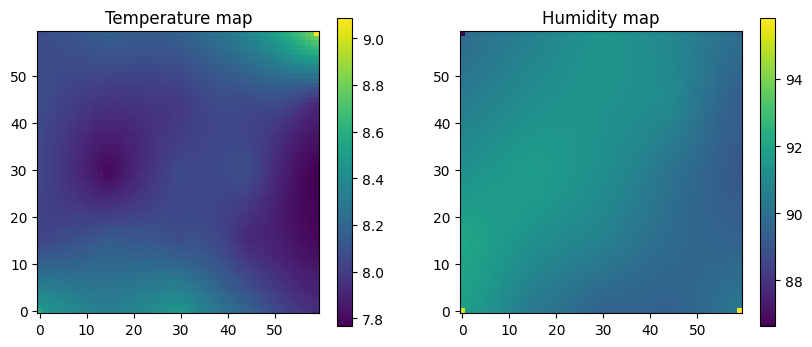

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(temp_stack[100], origin="lower")
plt.title("Temperature map")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(humid_stack[100], origin="lower")
plt.title("Humidity map")
plt.colorbar()

plt.show()

In [ ]:
print("Mean:", combined_scaled.mean())
print("Std:", combined_scaled.std())

Mean: 2.2659775e-07
Std: 1.0


#Field Clustering

In [ ]:
import numpy as np
import os

BASE_PATH = "/content/drive/MyDrive/Microclimate-data"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

temp_stack = np.load(
    os.path.join(PROCESSED_PATH,
                 "kriging_temperature_stack.npy")
)

hum_stack = np.load(
    os.path.join(PROCESSED_PATH,
                 "kriging_humidity_stack.npy")
)

print("Temp stack:", temp_stack.shape)
print("Hum stack :", hum_stack.shape)

Temp stack: (3819, 60, 60)
Hum stack : (3819, 60, 60)


##Temperature Statistics

In [ ]:
temp_mean = temp_stack.mean(axis=0)
temp_std  = temp_stack.std(axis=0)
temp_min  = temp_stack.min(axis=0)
temp_max  = temp_stack.max(axis=0)
temp_rng  = temp_max - temp_min

##Humidity Statisitics

In [ ]:
hum_mean = hum_stack.mean(axis=0)
hum_std  = hum_stack.std(axis=0)
hum_min  = hum_stack.min(axis=0)
hum_max  = hum_stack.max(axis=0)
hum_rng  = hum_max - hum_min

##Cell Feature Matrix

In [ ]:
H, W = temp_mean.shape

cell_features = np.stack([
    temp_mean,
    temp_std,
    temp_rng,
    hum_mean,
    hum_std,
    hum_rng
], axis=-1)

cell_features = cell_features.reshape(-1, 6)

print("Cell feature matrix:", cell_features.shape)

Cell feature matrix: (3600, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cell_features_scaled = scaler.fit_transform(cell_features)

print("Scaled shape:", cell_features_scaled.shape)

Scaled shape: (3600, 6)


In [ ]:
np.save(
    os.path.join(PROCESSED_PATH,
                 "cell_microclimate_features.npy"),
    cell_features_scaled
)

print("✅ saved cell features")

✅ saved cell features


##PCA for Field Clustering

In [ ]:
import numpy as np
import os
from sklearn.decomposition import PCA

BASE_PATH = "/content/drive/MyDrive/Microclimate-data"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

X = np.load(
    os.path.join(PROCESSED_PATH,
                 "cell_microclimate_features.npy")
)

print("Feature matrix:", X.shape)

Feature matrix: (3600, 6)


In [ ]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(X)

In [ ]:
print("PCA shape:", X_pca.shape)
print("Explained variance:",
      pca.explained_variance_ratio_)
print("Total variance:",
      pca.explained_variance_ratio_.sum())

PCA shape: (3600, 5)
Explained variance: [0.34604874 0.27950874 0.17967647 0.13256884 0.0471386 ]
Total variance: 0.98494136


In [ ]:
np.save(
    os.path.join(PROCESSED_PATH,
                 "cell_features_pca.npy"),
    X_pca
)

print("✅ saved PCA features")

✅ saved PCA features


##Determining Number of Clusters

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Microclimate-data"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

X = np.load(
    os.path.join(PROCESSED_PATH,
                 "cell_features_pca.npy")
)

print("PCA cell features:", X.shape)

PCA cell features: (3600, 5)


In [ ]:
ks = range(2, 16)

sil_scores = []
db_scores  = []
inertias   = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)

    sil_scores.append(sil)
    db_scores.append(db)
    inertias.append(km.inertia_)

    print(f"k={k} | silhouette={sil:.4f} | DB={db:.4f} | inertia={km.inertia_:.1f}")

k=2 | silhouette=0.2683 | DB=1.5185 | inertia=16143.6
k=3 | silhouette=0.2639 | DB=1.2897 | inertia=13141.2
k=4 | silhouette=0.2965 | DB=1.1556 | inertia=10762.7
k=5 | silhouette=0.2953 | DB=1.2053 | inertia=9571.1
k=6 | silhouette=0.2940 | DB=1.1003 | inertia=8452.4
k=7 | silhouette=0.2942 | DB=1.1229 | inertia=7475.4
k=8 | silhouette=0.2980 | DB=1.0305 | inertia=6734.1
k=9 | silhouette=0.3059 | DB=1.0037 | inertia=6223.8
k=10 | silhouette=0.3150 | DB=0.9811 | inertia=5742.6
k=11 | silhouette=0.3065 | DB=0.9851 | inertia=5256.7
k=12 | silhouette=0.3147 | DB=0.9549 | inertia=4875.0
k=13 | silhouette=0.3145 | DB=0.9725 | inertia=4600.0
k=14 | silhouette=0.3061 | DB=1.0049 | inertia=4362.4
k=15 | silhouette=0.3010 | DB=1.0221 | inertia=4159.2


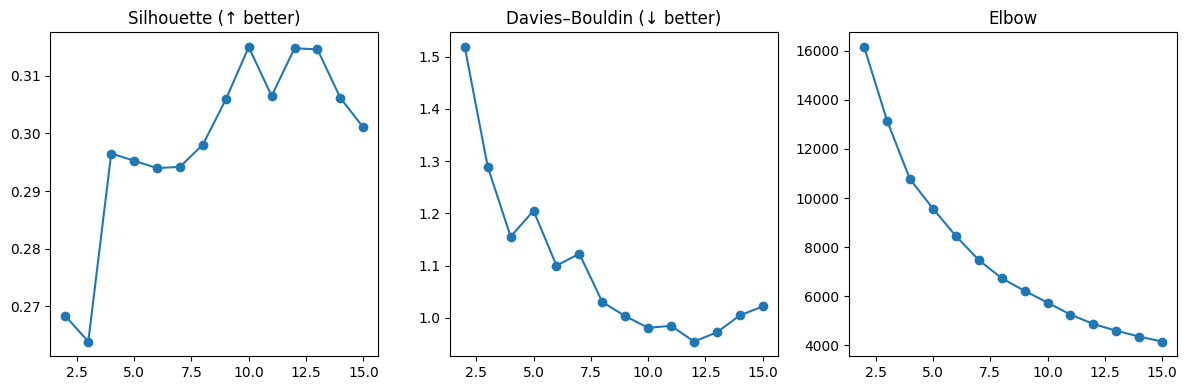

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(ks, sil_scores, marker="o")
plt.title("Silhouette (↑ better)")

plt.subplot(1,3,2)
plt.plot(ks, db_scores, marker="o")
plt.title("Davies–Bouldin (↓ better)")

plt.subplot(1,3,3)
plt.plot(ks, inertias, marker="o")
plt.title("Elbow")

plt.tight_layout()
plt.show()

In [ ]:
sil = np.array(sil_scores)
db  = np.array(db_scores)
iner = np.array(inertias)

sil_norm  = (sil - sil.min()) / (sil.max() - sil.min())
db_norm   = (db.max() - db) / (db.max() - db.min())
iner_norm = (iner.max() - iner) / (iner.max() - iner.min())

combined = sil_norm + db_norm + iner_norm

best_k = ks[np.argmax(combined)]

print("✅ Automatic best k =", best_k)

✅ Automatic best k = 12


##Final field clustering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

temp_stack = np.load(
    os.path.join(PROCESSED_PATH,
                 "kriging_temperature_stack.npy")
)

humid_stack = np.load(
    os.path.join(PROCESSED_PATH,
                 "kriging_humidity_stack.npy")
)

In [ ]:
k_final = best_k

kmeans = KMeans(
    n_clusters=k_final,
    n_init=30,
    random_state=42
)

cell_labels = kmeans.fit_predict(X)

print("Cluster counts:",
      np.bincount(cell_labels))

Cluster counts: [526 162 388 210 326  22 396  93 552  76 293 556]


In [ ]:
np.save(
    os.path.join(PROCESSED_PATH,
                 "field_cluster_labels.npy"),
    cell_labels
)

print("✅ labels saved")

✅ labels saved


###Plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter, median_filter, generic_filter

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "cell_features_pca.npy"))
temp_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_temperature_stack.npy"))
humid_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_humidity_stack.npy"))

print(X.shape, temp_stack.shape, humid_stack.shape)

(3600, 5) (3819, 60, 60) (3819, 60, 60)


In [ ]:
k_final = 12

kmeans = KMeans(n_clusters=k_final, n_init=30, random_state=42)
labels = kmeans.fit_predict(X)

np.save(os.path.join(PROCESSED_PATH, "field_cluster_labels.npy"), labels)

print("Cluster counts:", np.bincount(labels))

Cluster counts: [526 162 388 210 326  22 396  93 552  76 293 556]


In [ ]:
_, H, W = temp_stack.shape

zone_map = labels.reshape(H, W)

np.save(os.path.join(PROCESSED_PATH, "field_zone_map.npy"), zone_map)

In [ ]:
zone_med = median_filter(zone_map, size=5)

def majority(vals):
    v,c = np.unique(vals, return_counts=True)
    return v[np.argmax(c)]

zone_smooth = generic_filter(zone_med, majority, size=5)

np.save(os.path.join(PROCESSED_PATH, "field_zone_map_smooth.npy"),
        zone_smooth)

In [ ]:
temp_mean = temp_stack.mean(axis=0)
humid_mean = humid_stack.mean(axis=0)

temp_smooth = gaussian_filter(temp_mean, sigma=1.2)
humid_smooth = gaussian_filter(humid_mean, sigma=1.2)

In [ ]:
center_lat = 45.392
center_lon = 9.6967

lat_half = 300 / 111320 / 2
lon_half = 300 / (111320 * np.cos(np.deg2rad(center_lat))) / 2

lat_min = center_lat - lat_half
lat_max = center_lat + lat_half
lon_min = center_lon - lon_half
lon_max = center_lon + lon_half

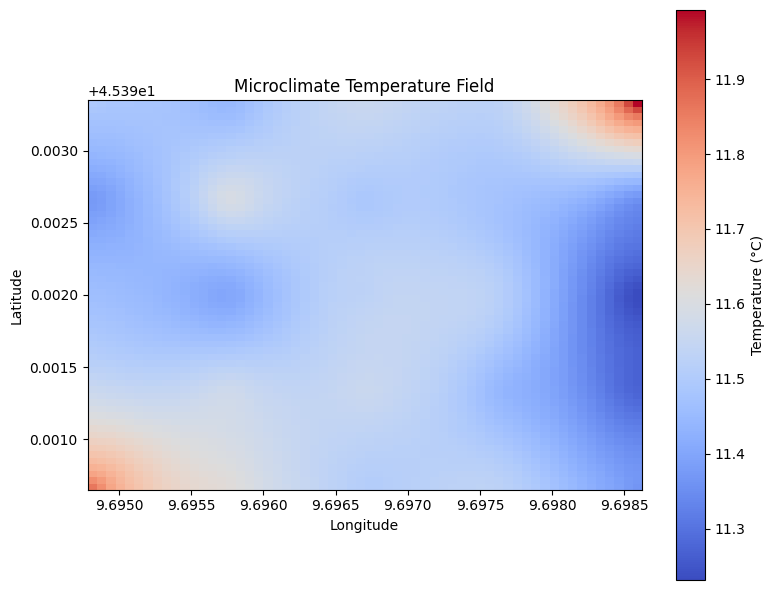

In [ ]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    temp_smooth,
    cmap="coolwarm",
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower"
)

plt.colorbar(im, label="Temperature (°C)")
plt.title("Microclimate Temperature Field")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

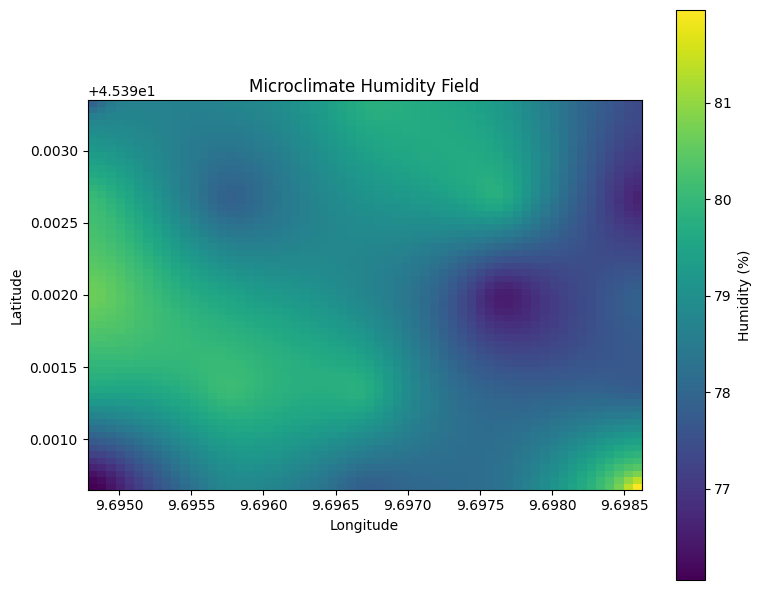

In [ ]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    humid_smooth,
    cmap="viridis",
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower"
)

plt.colorbar(im, label="Humidity (%)")
plt.title("Microclimate Humidity Field")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

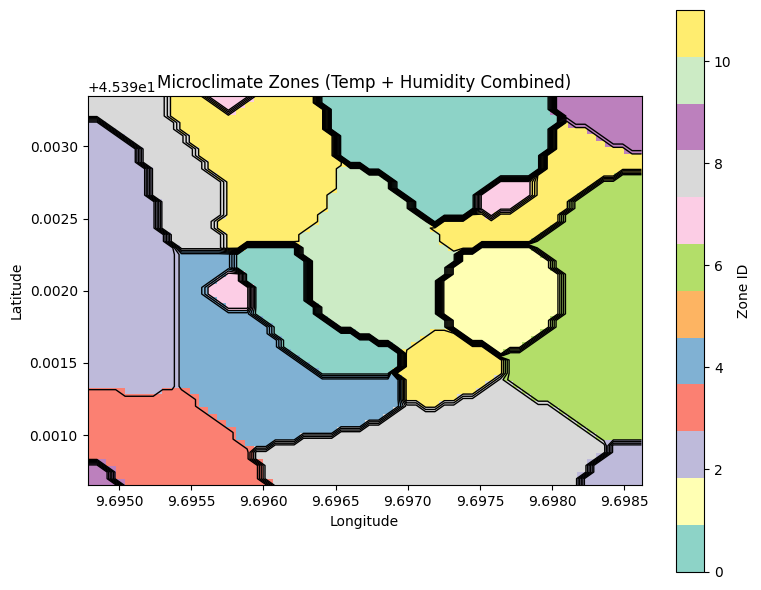

In [ ]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    zone_smooth,
    cmap="Set3",
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower",
    interpolation="nearest"
)

plt.contour(
    zone_smooth,
    levels=np.arange(k_final)+0.5,
    colors="black",
    linewidths=1,
    extent=[lon_min, lon_max, lat_min, lat_max]
)

plt.colorbar(im, label="Zone ID")

plt.title("Microclimate Zones (Temp + Humidity Combined)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

#Optimal Sensor Placement

In [ ]:
import pandas as pd
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

zone_map = np.load(os.path.join(PROCESSED_PATH,
                                "field_zone_map_smooth.npy"))

sensor_coords = pd.read_csv(
    os.path.join(PROCESSED_PATH,
                 "sensor_coordinates.csv")
)

print(sensor_coords.head())

   sensor_id   latitude  longitude
0          1  45.390589   9.694759
1          2  45.390589   9.695715
2          3  45.390589   9.696670
3          4  45.390589   9.697625
4          5  45.390589   9.698581


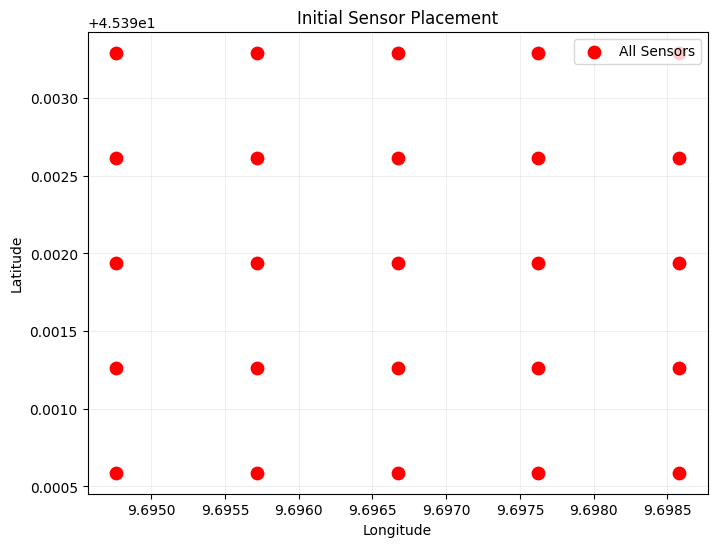

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    sensor_coords.longitude,
    sensor_coords.latitude,
    c="red",
    s=80,
    label="All Sensors"
)

plt.title("Initial Sensor Placement")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
from scipy import ndimage

In [ ]:
zone_map = np.load(
    os.path.join(PROCESSED_PATH, "field_zone_map.npy")
)

zones = np.unique(zone_map)

centroid_points = []

for z in zones:

    mask = (zone_map == z)

    # find connected components inside this zone
    labeled, num = ndimage.label(mask)

    if num == 0:
        continue

    # find largest component
    sizes = ndimage.sum(mask, labeled, range(1, num+1))
    largest_label = np.argmax(sizes) + 1

    ys, xs = np.where(labeled == largest_label)

    # centroid of this blob
    y_center = int(ys.mean())
    x_center = int(xs.mean())

    lat_c = lat_mesh[y_center, x_center]
    lon_c = lon_mesh[y_center, x_center]

    centroid_points.append((z, lon_c, lat_c))

centroid_df = pd.DataFrame(
    centroid_points,
    columns=["zone_id","longitude","latitude"]
)

print("Zones:", len(zones))
print("Centroids placed:", len(centroid_df))

Zones: 12
Centroids placed: 12


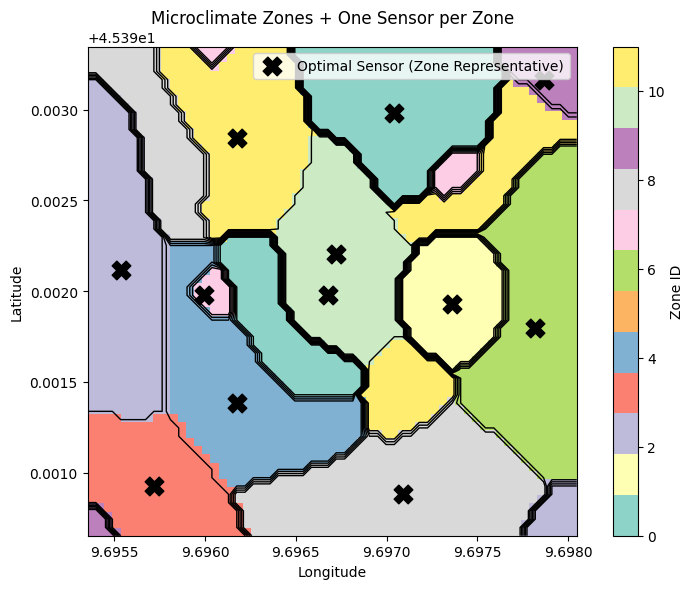

In [ ]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    zone_smooth,
    cmap="Set3",
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower",
    interpolation="nearest"
)

plt.contour(
    zone_smooth,
    levels=np.arange(len(zones)),
    colors="black",
    linewidths=1,
    extent=[lon_min, lon_max, lat_min, lat_max]
)

plt.scatter(
    centroid_df["longitude"],
    centroid_df["latitude"],
    c="black",
    s=180,
    marker="X",
    label="Optimal Sensor (Zone Representative)"
)

plt.colorbar(im, label="Zone ID")
plt.title("Microclimate Zones + One Sensor per Zone")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

#Load+Clean ERA5

In [ ]:
!pip install cfgrib xarray eccodes -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.3 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os

ERA5_PATH = "/content/drive/MyDrive/Microclimate-data/data_era5"

field_lat = 45.39
field_lon = 9.695

# Collect all GRIB files

era5_files = sorted(
    glob.glob(os.path.join(ERA5_PATH, "*.grib"))
)

print("Found ERA5 files:", len(era5_files))

all_months = []

# Loop through files

for f in era5_files:

    print("Loading:", os.path.basename(f))

    ds = xr.open_dataset(
        f,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {"typeOfLevel": "surface"}
        }
    )

    # select nearest grid cell

    ds_point = ds.sel(
        latitude=field_lat,
        longitude=field_lon,
        method="nearest"
    )

    df = ds_point.to_dataframe().reset_index()

    # unit conversions

    df["t2m_c"] = df["t2m"] - 273.15
    df["d2m_c"] = df["d2m"] - 273.15
    df["sp_hpa"] = df["sp"] / 100

    # keep only useful columns

    keep_cols = [
        "time",
        "t2m_c",
        "d2m_c",
        "sp_hpa",
        "u10",
        "v10",
        "tcc"
    ]

    df = df[keep_cols]

    all_months.append(df)

# Combine all months

era5_df = pd.concat(all_months)
era5_df = era5_df.sort_values("time")
era5_df = era5_df.drop_duplicates("time")

print("\nERA5 combined shape:", era5_df.shape)
print(era5_df.head())


Found ERA5 files: 8
Loading: DataERA5_2022_11.grib


ERROR:cfgrib.dataset:skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1667260800, 1667264400, 1667268000, 1667271600, 1667275200,
       1667278800, 1667282400, 1667286000, 1667289600, 1667293200,
       1667296800, 1667300400, 1667304000, 1667307600, 1667311200,
       1667314800, 1667318400, 1667322000, 1667325600, 1667329200,
       1667332800, 1667336400, 1667340000, 1667343600, 1667347200,
       1667350800, 1667354400, 1667358000, 1667361600, 1667365200,
       1667368800, 1667372400, 1667376000, 1667379600, 1667383200,
       1667386800, 1667390400, 166

Loading: DataERA5_2022_12.grib


ERROR:cfgrib.dataset:skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1669852800, 1669856400, 1669860000, 1669863600, 1669867200,
       1669870800, 1669874400, 1669878000, 1669881600, 1669885200,
       1669888800, 1669892400, 1669896000, 1669899600, 1669903200,
       1669906800, 1669910400, 1669914000, 1669917600, 1669921200,
       1669924800, 1669928400, 1669932000, 1669935600, 1669939200,
       1669942800, 1669946400, 1669950000, 1669953600, 1669957200,
       1669960800, 1669964400, 1669968000, 1669971600, 1669975200,
       1669978800, 1669982400, 166

Loading: DataERA5_2023_01.grib


...

Loading: DataERA5_2023_05.grib


ERROR:cfgrib.dataset:skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1682899200, 1682902800, 1682906400, 1682910000, 1682913600,
       1682917200, 1682920800, 1682924400, 1682928000, 1682931600,
       1682935200, 1682938800, 1682942400, 1682946000, 1682949600,
       1682953200, 1682956800, 1682960400, 1682964000, 1682967600,
       1682971200, 1682974800, 1682978400, 1682982000, 1682985600,
       1682989200, 1682992800, 1682996400, 1683000000, 1683003600,
       1683007200, 1683010800, 1683014400, 1683018000, 1683021600,
       1683025200, 1683028800, 168

Loading: DataERA5_2023_06.grib


ERROR:cfgrib.dataset:skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1685577600, 1685581200, 1685584800, 1685588400, 1685592000,
       1685595600, 1685599200, 1685602800, 1685606400, 1685610000,
       1685613600, 1685617200, 1685620800, 1685624400, 1685628000,
       1685631600, 1685635200, 1685638800, 1685642400, 1685646000,
       1685649600, 1685653200, 1685656800, 1685660400, 1685664000,
       1685667600, 1685671200, 1685674800, 1685678400, 1685682000,
       1685685600, 1685689200, 1685692800, 1685696400, 1685700000,
       1685703600, 1685707200, 168


ERA5 combined shape: (5616, 7)
                 time      t2m_c     d2m_c       sp_hpa       u10       v10  \
0 2022-11-01 00:00:00  11.082672  8.555328   999.995605  1.331558 -0.190308   
1 2022-11-01 01:00:00  10.735504  8.311920  1000.041260  1.024597 -0.811707   
2 2022-11-01 02:00:00  10.697662  8.470367   999.885010  0.782730 -1.083405   
3 2022-11-01 03:00:00  10.875885  8.802155   999.712524  0.706451 -1.201080   
4 2022-11-01 04:00:00  10.881989  8.712311   999.442505  0.681900 -1.541611   

        tcc  
0  0.955963  
1  0.945953  
2  0.925964  
3  0.950012  
4  0.852112  


In [ ]:
PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

era5_df.to_csv(
    os.path.join(PROCESSED_PATH, "era5_field_timeseries.csv"),
    index=False
)

print("Saved ERA5 processed file")

Saved ERA5 processed file


In [ ]:
print(era5_df.describe())
print(era5_df.isna().sum())

                                time        t2m_c        d2m_c       sp_hpa  \
count                           5616  5616.000000  5616.000000  5616.000000   
mean   2023-02-25 23:30:00.000000256    11.038773     6.256871   994.225403   
min              2022-11-01 00:00:00    -3.912384   -12.447113   965.213745   
25%              2022-12-29 11:45:00     5.936371     2.510620   989.854675   
50%              2023-02-25 23:30:00    10.113434     6.047516   994.232483   
75%              2023-04-25 11:15:00    15.336212    10.329987   998.733887   
max              2023-06-22 23:00:00    33.486725    19.141022  1016.484375   
std                              NaN     6.711975     5.789913     8.449123   

               u10          v10          tcc  
count  5616.000000  5616.000000  5616.000000  
mean      0.056331    -0.204029     0.626186  
min      -4.532974    -5.493774     0.000000  
25%      -0.841026    -0.850365     0.313599  
50%       0.092033    -0.227921     0.731705  
75%   

#Forecasting

##Build Zone Mean Time Series

In [ ]:
import numpy as np
import pandas as pd
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

# Load stacks and zone map
temp_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_temperature_stack.npy"))
humid_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_humidity_stack.npy"))
zone_map = np.load(os.path.join(PROCESSED_PATH, "field_zone_map.npy"))

print("Temp stack shape:", temp_stack.shape)
print("Humid stack shape:", humid_stack.shape)
print("Zone map shape:", zone_map.shape)

Temp stack shape: (3819, 60, 60)
Humid stack shape: (3819, 60, 60)
Zone map shape: (60, 60)


In [ ]:
# Load timestamps
temp_times = pd.read_csv(
    os.path.join(PROCESSED_PATH, "kriging_temp_times.csv")
).iloc[:, 0]

humid_times = pd.read_csv(
    os.path.join(PROCESSED_PATH, "kriging_humid_times.csv")
).iloc[:, 0]

temp_times = pd.to_datetime(temp_times)
humid_times = pd.to_datetime(humid_times)

In [ ]:
# Get zone list
zones = np.unique(zone_map)
zones = zones[zones >= 0]   # ignore -1 if present
zones = zones.astype(int)

print("Zones:", zones)

Zones: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [ ]:
# Zone mean function
def build_zone_timeseries(stack, zone_map, zones):
    T = stack.shape[0]
    zone_series = {z: [] for z in zones}

    for t in range(T):
        frame = stack[t]
        for z in zones:
            mask = (zone_map == z)
            val = np.nanmean(frame[mask])
            zone_series[z].append(val)

    return pd.DataFrame(zone_series)

In [ ]:
# Compute zone time series
zone_temp_df = build_zone_timeseries(temp_stack, zone_map, zones)
zone_humid_df = build_zone_timeseries(humid_stack, zone_map, zones)

zone_temp_df.insert(0, "time", temp_times.values)
zone_humid_df.insert(0, "time", humid_times.values)

print(zone_temp_df.head())

                 time          0          1          2          3          4  \
0 2022-11-11 12:00:00  20.177141  20.190304  20.186104  20.280022  20.208149   
1 2022-11-11 13:00:00  18.949383  18.832890  18.854101  19.192060  19.240862   
2 2022-11-11 14:00:00  15.922789  15.749090  15.810975  15.938300  16.101934   
3 2022-11-11 15:00:00  14.502596  14.361090  14.283503  14.468975  14.524025   
4 2022-11-11 16:00:00  12.642586  12.706751  12.632573  12.647828  12.632666   

           5          6          7          8          9         10         11  
0  20.198952  20.108990  20.169531  20.176266  20.186483  20.186167  20.181431  
1  19.038219  18.679346  18.873846  19.052094  19.067963  19.001669  18.863768  
2  15.850994  15.616867  15.904412  15.957710  15.933394  15.904214  15.859336  
3  14.474430  14.108206  14.366261  14.458263  14.788407  14.463000  14.403934  
4  12.819705  12.612159  12.580292  12.644603  12.732140  12.697324  12.637595  


In [ ]:
zone_temp_df.to_csv(
    os.path.join(PROCESSED_PATH, "zone_temperature_timeseries.csv"),
    index=False
)

zone_humid_df.to_csv(
    os.path.join(PROCESSED_PATH, "zone_humidity_timeseries.csv"),
    index=False
)

print("✅ Zone time series saved")

✅ Zone time series saved


##Merge Zone Series + ERA5

In [ ]:
import pandas as pd
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

# Load zone series
zone_temp_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "zone_temperature_timeseries.csv"),
    parse_dates=["time"]
)

zone_humid_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "zone_humidity_timeseries.csv"),
    parse_dates=["time"]
)

# Load ERA5 features
era5_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "era5_field_timeseries.csv"),
    parse_dates=["time"]
)

print("Zone temp shape:", zone_temp_df.shape)
print("Zone humid shape:", zone_humid_df.shape)
print("ERA5 shape:", era5_df.shape)

Zone temp shape: (3819, 13)
Zone humid shape: (3819, 13)
ERA5 shape: (5616, 7)


In [ ]:
zone_temp_df = zone_temp_df.drop_duplicates("time")
zone_humid_df = zone_humid_df.drop_duplicates("time")
era5_df = era5_df.drop_duplicates("time")

In [ ]:
temp_full_df = pd.merge(
    zone_temp_df,
    era5_df,
    on="time",
    how="inner"
)

humid_full_df = pd.merge(
    zone_humid_df,
    era5_df,
    on="time",
    how="inner"
)

print("Merged temp shape:", temp_full_df.shape)
print("Merged humid shape:", humid_full_df.shape)

Merged temp shape: (3809, 19)
Merged humid shape: (3809, 19)


In [ ]:
print("Temp NaNs:", temp_full_df.isna().sum().sum())
print("Humid NaNs:", humid_full_df.isna().sum().sum())

Temp NaNs: 0
Humid NaNs: 0


In [ ]:
temp_full_df = temp_full_df.interpolate()
humid_full_df = humid_full_df.interpolate()

In [ ]:
temp_full_df.to_csv(
    os.path.join(PROCESSED_PATH, "temp_model_table.csv"),
    index=False
)

humid_full_df.to_csv(
    os.path.join(PROCESSED_PATH, "humid_model_table.csv"),
    index=False
)

print("Model tables saved")

Model tables saved


##Generalised Window Builder

In [ ]:
import numpy as np

def build_windows(df, time_col="time", zone_cols=None, window=72, horizon=24):
    """
    Builds sliding windows for forecasting

    X → past window (zones + ERA5)
    Y → future horizon (zones only)
    """

    df = df.sort_values(time_col).reset_index(drop=True)

    # identify columns
    if zone_cols is None:
        zone_cols = [c for c in df.columns if c.startswith("zone")]

    feature_cols = [c for c in df.columns if c != time_col]

    X_list = []
    Y_list = []

    values = df[feature_cols].values
    zone_values = df[zone_cols].values

    total = len(df)

    # sliding window
    for i in range(total - window - horizon + 1):

        X_window = values[i : i + window]
        Y_window = zone_values[i + window : i + window + horizon]

        X_list.append(X_window)
        Y_list.append(Y_window)

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)

    return X, Y, feature_cols, zone_cols

##Input = 3 days

###Window Builder for Temperature

In [ ]:
import pandas as pd
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "temp_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in temp_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_temp, Y_temp, feat_cols, zone_cols = build_windows(
    temp_df,
    zone_cols=zone_cols,
    window=72,     # change later for 96 / 120
    horizon=24
)

print("X_temp shape:", X_temp.shape)
print("Y_temp shape:", Y_temp.shape)

X_temp shape: (3714, 72, 18)
Y_temp shape: (3714, 24, 12)


###Window Builder for Humidity

In [ ]:
humid_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "humid_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in humid_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_humid, Y_humid, _, _ = build_windows(
    humid_df,
    zone_cols=zone_cols,
    window=72,
    horizon=24
)

print("X_humid shape:", X_humid.shape)
print("Y_humid shape:", Y_humid.shape)

X_humid shape: (3714, 72, 18)
Y_humid shape: (3714, 24, 12)


In [ ]:
np.save(f"{PROCESSED_PATH}/X_temp_w72.npy", X_temp)
np.save(f"{PROCESSED_PATH}/Y_temp_w72.npy", Y_temp)

np.save(f"{PROCESSED_PATH}/X_humid_w72.npy", X_humid)
np.save(f"{PROCESSED_PATH}/Y_humid_w72.npy", Y_humid)

###Time-Series Train/Val/Test Split

In [ ]:
def time_split(X, Y, train=0.7, val=0.15):
    n = len(X)

    i_train = int(n * train)
    i_val = int(n * (train + val))

    return (
        X[:i_train], Y[:i_train],
        X[i_train:i_val], Y[i_train:i_val],
        X[i_val:], Y[i_val:]
    )

###General Forecast Model Builder (LSTM & GRU)

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(model_type, input_shape, horizon, n_zones):

    inp = keras.Input(shape=input_shape)

    if model_type == "LSTM":
        x = layers.LSTM(128, return_sequences=False)(inp)

    elif model_type == "GRU":
        x = layers.GRU(128, return_sequences=False)(inp)

    else:
        raise ValueError("Unsupported model_type")

    x = layers.Dense(128, activation="relu")(x)

    # output = horizon × zones
    out = layers.Dense(horizon * n_zones)(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

###Temperature (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2599, 72, 18)
Val: (557, 72, 18)
Test: (558, 72, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 72, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 92.0639 - mae: 7.9436 - val_loss: 132.8128 - val_mae: 10.5294
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.0194 - mae: 4.2515 - val_loss: 77.8510 - val_mae: 7.5501
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27.7543 - mae: 4.1149 - val_loss: 73.8483 - val_mae: 7.2871
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27.2169 - mae: 4.1103 - val_loss: 68.1772 - val_mae: 6.8911
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24.9838 - mae: 3.9193 - val_loss: 52.9733 - val_mae: 5.8040
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.0375 - mae: 3.6310 - val_loss: 38.6155 - val_mae: 4.6174
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18.6775 - mae: 3.2785 - val_loss: 28.7715 - val_mae: 3.7999
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.9513 - mae: 3.0597 - val_loss: 24.1947 - val_mae: 3.4831
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (558, 24, 12)
True shape: (558, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 6.7556252
Overall MAE: 5.2158213


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=6.820  MAE=5.275
Zone 1: RMSE=6.601  MAE=5.107
Zone 2: RMSE=6.784  MAE=5.219
Zone 3: RMSE=6.853  MAE=5.278
Zone 4: RMSE=6.927  MAE=5.344
Zone 5: RMSE=6.196  MAE=4.857
Zone 6: RMSE=6.860  MAE=5.270
Zone 7: RMSE=7.023  MAE=5.396
Zone 8: RMSE=6.893  MAE=5.313
Zone 9: RMSE=6.627  MAE=5.107
Zone 10: RMSE=6.622  MAE=5.143
Zone 11: RMSE=6.824  MAE=5.281


###Humidity (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2599, 72, 18)
Val: (557, 72, 18)
Test: (558, 72, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 72, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 6183.6499 - mae: 76.9881 - val_loss: 6091.3135 - val_mae: 77.1995
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4523.4058 - mae: 65.0404 - val_loss: 2454.3586 - val_mae: 48.1316
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1372.7478 - mae: 33.5522 - val_loss: 306.2459 - val_mae: 15.7648
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 272.9702 - mae: 13.8488 - val_loss: 177.0301 - val_mae: 11.9226
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 200.8777 - mae: 11.4263 - val_loss: 148.4070 - val_mae: 10.7205
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 187.0423 - mae: 10.8372 - val_loss: 141.8648 - val_mae: 10.3717
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 168.3812 - mae: 10.1282 - val_loss: 130.3243 - val_mae: 9.6959
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 156.6500 - mae: 9.5530 - val_loss: 131.2667 - val_mae: 9.6721
Epoch 9/30
41/41 ━━━

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (558, 24, 12)
True shape: (558, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 12.985167
Overall MAE: 10.437221


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.381  MAE=10.664
Zone 1: RMSE=12.854  MAE=10.525
Zone 2: RMSE=12.192  MAE=9.637
Zone 3: RMSE=12.032  MAE=9.680
Zone 4: RMSE=12.997  MAE=10.373
Zone 5: RMSE=12.409  MAE=10.178
Zone 6: RMSE=13.100  MAE=10.641
Zone 7: RMSE=13.640  MAE=10.834
Zone 8: RMSE=13.165  MAE=10.593
Zone 9: RMSE=13.666  MAE=10.935
Zone 10: RMSE=12.697  MAE=10.302
Zone 11: RMSE=13.558  MAE=10.883


###Temperature (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2599, 72, 18)
Val: (557, 72, 18)
Test: (558, 72, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 72, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 85.3755 - mae: 7.6057 - val_loss: 89.7100 - val_mae: 8.1929
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 27.9587 - mae: 4.1841 - val_loss: 65.8859 - val_mae: 6.7285
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25.0821 - mae: 3.9309 - val_loss: 55.0588 - val_mae: 5.9470
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.7928 - mae: 3.7145 - val_loss: 48.1393 - val_mae: 5.4311
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.7552 - mae: 3.6173 - val_loss: 41.6885 - val_mae: 4.8663
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.7855 - mae: 3.3857 - val_loss: 33.7508 - val_mae: 4.2034
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.8764 - mae: 3.1905 - val_loss: 29.7705 - val_mae: 3.8970
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.3853 - mae: 3.0782 - val_loss: 24.0681 - val_mae: 3.5533
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - lo

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (558, 24, 12)
True shape: (558, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 5.8048415
Overall MAE: 4.4763293


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=5.862  MAE=4.532
Zone 1: RMSE=5.659  MAE=4.360
Zone 2: RMSE=5.839  MAE=4.490
Zone 3: RMSE=5.903  MAE=4.555
Zone 4: RMSE=5.965  MAE=4.610
Zone 5: RMSE=5.247  MAE=4.087
Zone 6: RMSE=5.914  MAE=4.536
Zone 7: RMSE=6.071  MAE=4.671
Zone 8: RMSE=5.942  MAE=4.578
Zone 9: RMSE=5.684  MAE=4.389
Zone 10: RMSE=5.677  MAE=4.391
Zone 11: RMSE=5.851  MAE=4.516


###Humidity (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2599, 72, 18)
Val: (557, 72, 18)
Test: (558, 72, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 72, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 257.8724 - mae: 12.6535 - val_loss: 174.8282 - val_mae: 11.7723
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 248.7438 - mae: 12.6823 - val_loss: 176.6145 - val_mae: 11.8449
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 258.5143 - mae: 12.9947 - val_loss: 170.5758 - val_mae: 11.5994
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 253.2110 - mae: 12.7284 - val_loss: 177.4061 - val_mae: 11.8766
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 250.2590 - mae: 12.7479 - val_loss: 172.9462 - val_mae: 11.6974
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 259.9194 - mae: 12.9844 - val_loss: 165.3824 - val_mae: 11.3742
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 247.4210 - mae: 12.6857 - val_loss: 178.1087 - val_mae: 11.9040
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 256.3990 - mae: 12.9330 - val_loss: 173.6609 - val_mae: 11.7266
Epoch 9/30
41/41

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (558, 24, 12)
True shape: (558, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 13.279338
Overall MAE: 10.973779


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.720  MAE=11.235
Zone 1: RMSE=13.328  MAE=11.243
Zone 2: RMSE=12.232  MAE=9.913
Zone 3: RMSE=11.961  MAE=9.896
Zone 4: RMSE=13.111  MAE=10.740
Zone 5: RMSE=12.959  MAE=10.950
Zone 6: RMSE=13.504  MAE=11.272
Zone 7: RMSE=13.915  MAE=11.349
Zone 8: RMSE=13.363  MAE=11.023
Zone 9: RMSE=13.983  MAE=11.544
Zone 10: RMSE=13.180  MAE=11.014
Zone 11: RMSE=13.924  MAE=11.506


###NHITS Model

In [ ]:
!pip -q install neuralforecast

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [ ]:
import pandas as pd

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(f"{PROCESSED_PATH}/zone_temperature_timeseries.csv", index_col=0, parse_dates=True)
humid_df = pd.read_csv(f"{PROCESSED_PATH}/zone_humidity_timeseries.csv", index_col=0, parse_dates=True)
era5_df = pd.read_csv(f"{PROCESSED_PATH}/era5_field_timeseries.csv", parse_dates=["time"])

era5_df = era5_df.set_index("time")

In [ ]:
common_index = temp_df.index.intersection(humid_df.index).intersection(era5_df.index)

temp_df = temp_df.loc[common_index]
humid_df = humid_df.loc[common_index]
era5_df = era5_df.loc[common_index]

###Temperature (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in temp_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": temp_df.index,
        "y": temp_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_temp_df = pd.concat(rows).reset_index(drop=True)

nf_temp_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,20.177141,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,18.949383,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,15.922789,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,14.502596,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,12.642586,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_temp_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_temp_df[nf_temp_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=72,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,21.176279
1,zone_0,2023-06-22 01:00:00,20.954386
2,zone_0,2023-06-22 02:00:00,20.405394
3,zone_0,2023-06-22 03:00:00,20.030880
4,zone_0,2023-06-22 04:00:00,19.637377


In [ ]:
test_df = nf_temp_df[nf_temp_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 2.4718606138734356
NHITS MAE: 1.9294295284152563


###Humidity (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in humid_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": humid_df.index,
        "y": humid_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_humid_df = pd.concat(rows).reset_index(drop=True)

nf_humid_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,67.526070,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,66.467260,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,73.595566,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,79.371170,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,82.240480,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_humid_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_humid_df[nf_humid_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=72,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,77.392838
1,zone_0,2023-06-22 01:00:00,77.489403
2,zone_0,2023-06-22 02:00:00,78.020454
3,zone_0,2023-06-22 03:00:00,78.903046
4,zone_0,2023-06-22 04:00:00,80.997894


In [ ]:
test_df = nf_humid_df[nf_humid_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 7.573847273804899
NHITS MAE: 6.16137995711263


###Transformer Based Models

####Informer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w72.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w72.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3714, 72, 18)
Y shape: (3714, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3714, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3714, 72, 18]) torch.Size([3714, 36, 12]) torch.Size([3714, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.3336
Epoch 2, Loss: 0.2805
Epoch 3, Loss: 0.2670
Epoch 4, Loss: 0.2626
Epoch 5, Loss: 0.2590
Epoch 6, Loss: 0.2572
Epoch 7, Loss: 0.2554
Epoch 8, Loss: 0.2567
Epoch 9, Loss: 0.2529
Epoch 10, Loss: 0.2516


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.120463876806102
MAE: 7.372228622436523


####Informer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w72.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w72.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3714, 72, 18)
Y shape: (3714, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3714, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3714, 72, 18]) torch.Size([3714, 36, 12]) torch.Size([3714, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.5596
Epoch 2, Loss: 0.4229
Epoch 3, Loss: 0.3944
Epoch 4, Loss: 0.3710
Epoch 5, Loss: 0.3620
Epoch 6, Loss: 0.3525
Epoch 7, Loss: 0.3457
Epoch 8, Loss: 0.3410
Epoch 9, Loss: 0.3393
Epoch 10, Loss: 0.3382


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 19.915934316452883
MAE: 15.514925003051758


###Autoformer

####Autoformer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w72.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w72.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3714, 72, 18)
Y shape: (3714, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3714, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

KeyboardInterrupt: 

In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

####Autoformer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w72.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w72.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3714, 72, 18)
Y shape: (3714, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3714, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6083
Epoch 2, Loss: 0.4633
Epoch 3, Loss: 0.4038
Epoch 4, Loss: 0.3750
Epoch 5, Loss: 0.3565
Epoch 6, Loss: 0.3360
Epoch 7, Loss: 0.3182
Epoch 8, Loss: 0.3150
Epoch 9, Loss: 0.2805
Epoch 10, Loss: 0.2555


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 20.938188683869676
MAE: 16.46413803100586


##Input = 2 days

###Window Builder for Temperature

In [ ]:
import pandas as pd
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "temp_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in temp_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_temp, Y_temp, feat_cols, zone_cols = build_windows(
    temp_df,
    zone_cols=zone_cols,
    window=48,     # change later for 96 / 120
    horizon=24
)

print("X_temp shape:", X_temp.shape)
print("Y_temp shape:", Y_temp.shape)

X_temp shape: (3738, 48, 18)
Y_temp shape: (3738, 24, 12)


###Window Builder for Humidity

In [ ]:
humid_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "humid_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in humid_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_humid, Y_humid, _, _ = build_windows(
    humid_df,
    zone_cols=zone_cols,
    window=48,
    horizon=24
)

print("X_humid shape:", X_humid.shape)
print("Y_humid shape:", Y_humid.shape)

X_humid shape: (3738, 48, 18)
Y_humid shape: (3738, 24, 12)


In [ ]:
np.save(f"{PROCESSED_PATH}/X_temp_w48.npy", X_temp)
np.save(f"{PROCESSED_PATH}/Y_temp_w48.npy", Y_temp)

np.save(f"{PROCESSED_PATH}/X_humid_w48.npy", X_humid)
np.save(f"{PROCESSED_PATH}/Y_humid_w48.npy", Y_humid)

###Time-Series Train/Val/Test Split

In [ ]:
def time_split(X, Y, train=0.7, val=0.15):
    n = len(X)

    i_train = int(n * train)
    i_val = int(n * (train + val))

    return (
        X[:i_train], Y[:i_train],
        X[i_train:i_val], Y[i_train:i_val],
        X[i_val:], Y[i_val:]
    )

###General Forecast Model Builder (LSTM & GRU)

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(model_type, input_shape, horizon, n_zones):

    inp = keras.Input(shape=input_shape)

    if model_type == "LSTM":
        x = layers.LSTM(128, return_sequences=False)(inp)

    elif model_type == "GRU":
        x = layers.GRU(128, return_sequences=False)(inp)

    else:
        raise ValueError("Unsupported model_type")

    x = layers.Dense(128, activation="relu")(x)

    # output = horizon × zones
    out = layers.Dense(horizon * n_zones)(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

###Temperature (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2616, 48, 18)
Val: (561, 48, 18)
Test: (561, 48, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 87.1930 - mae: 7.7675 - val_loss: 134.7217 - val_mae: 10.6187
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 30.9069 - mae: 4.2396 - val_loss: 76.5016 - val_mae: 7.4559
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 28.1731 - mae: 4.1809 - val_loss: 79.1024 - val_mae: 7.6300
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27.7784 - mae: 4.1437 - val_loss: 73.2212 - val_mae: 7.2459
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25.7299 - mae: 3.9492 - val_loss: 58.1514 - val_mae: 6.1722
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.2940 - mae: 3.6596 - val_loss: 44.0326 - val_mae: 5.0684
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.9588 - mae: 3.3015 - val_loss: 29.4013 - val_mae: 3.8528
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.5938 - mae: 3.0350 - val_loss: 24.5080 - val_mae: 3.5166
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (561, 24, 12)
True shape: (561, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 6.185522
Overall MAE: 4.6817865


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=6.245  MAE=4.739
Zone 1: RMSE=6.049  MAE=4.585
Zone 2: RMSE=6.215  MAE=4.686
Zone 3: RMSE=6.280  MAE=4.745
Zone 4: RMSE=6.343  MAE=4.798
Zone 5: RMSE=5.637  MAE=4.329
Zone 6: RMSE=6.293  MAE=4.737
Zone 7: RMSE=6.443  MAE=4.857
Zone 8: RMSE=6.327  MAE=4.779
Zone 9: RMSE=6.059  MAE=4.584
Zone 10: RMSE=6.063  MAE=4.616
Zone 11: RMSE=6.234  MAE=4.728


###Humidity (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2616, 48, 18)
Val: (561, 48, 18)
Test: (561, 48, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6159.8403 - mae: 76.8313 - val_loss: 6162.6245 - val_mae: 77.6456
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4695.8330 - mae: 66.4004 - val_loss: 2654.9670 - val_mae: 50.1525
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1489.5470 - mae: 35.2311 - val_loss: 346.4699 - val_mae: 16.7860
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 276.6384 - mae: 14.0505 - val_loss: 158.8856 - val_mae: 11.1565
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 196.7173 - mae: 11.1995 - val_loss: 149.0635 - val_mae: 10.7195
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 179.7263 - mae: 10.5735 - val_loss: 154.2934 - val_mae: 10.8840
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 155.0055 - mae: 9.8032 - val_loss: 142.2598 - val_mae: 9.9800
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 141.2046 - mae: 9.1604 - val_loss: 150.2060 - val_mae: 10.2412
Epoch 9/30
41/41 ━━

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (561, 24, 12)
True shape: (561, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 13.014605
Overall MAE: 10.913187


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.227  MAE=11.030
Zone 1: RMSE=13.121  MAE=11.096
Zone 2: RMSE=12.058  MAE=10.022
Zone 3: RMSE=12.296  MAE=10.352
Zone 4: RMSE=12.873  MAE=10.774
Zone 5: RMSE=12.834  MAE=10.829
Zone 6: RMSE=13.248  MAE=11.192
Zone 7: RMSE=13.413  MAE=11.161
Zone 8: RMSE=13.163  MAE=11.088
Zone 9: RMSE=13.523  MAE=11.323
Zone 10: RMSE=12.898  MAE=10.845
Zone 11: RMSE=13.436  MAE=11.245


###Temperature (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2616, 48, 18)
Val: (561, 48, 18)
Test: (561, 48, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 85.1243 - mae: 7.5735 - val_loss: 89.8062 - val_mae: 8.1996
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28.2879 - mae: 4.2081 - val_loss: 67.8199 - val_mae: 6.8688
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.3922 - mae: 3.8542 - val_loss: 61.6887 - val_mae: 6.4283
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.7537 - mae: 3.6847 - val_loss: 51.0645 - val_mae: 5.6232
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 20.4846 - mae: 3.4520 - val_loss: 35.1270 - val_mae: 4.3120
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.9095 - mae: 3.3025 - val_loss: 33.0030 - val_mae: 4.1529
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.1817 - mae: 3.0919 - val_loss: 25.5568 - val_mae: 3.6048
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.0331 - mae: 2.9988 - val_loss: 32.0237 - val_mae: 4.1538
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (561, 24, 12)
True shape: (561, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 5.986232
Overall MAE: 4.5688114


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=6.039  MAE=4.621
Zone 1: RMSE=5.856  MAE=4.473
Zone 2: RMSE=6.037  MAE=4.591
Zone 3: RMSE=6.079  MAE=4.637
Zone 4: RMSE=6.149  MAE=4.695
Zone 5: RMSE=5.401  MAE=4.179
Zone 6: RMSE=6.087  MAE=4.619
Zone 7: RMSE=6.259  MAE=4.759
Zone 8: RMSE=6.133  MAE=4.672
Zone 9: RMSE=5.852  MAE=4.470
Zone 10: RMSE=5.849  MAE=4.486
Zone 11: RMSE=6.048  MAE=4.623


###Humidity (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2616, 48, 18)
Val: (561, 48, 18)
Test: (561, 48, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 262.0294 - mae: 12.7575 - val_loss: 172.1125 - val_mae: 11.6480
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 258.6307 - mae: 12.8668 - val_loss: 169.2924 - val_mae: 11.5299
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 252.8266 - mae: 12.8005 - val_loss: 172.9617 - val_mae: 11.6839
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 250.2714 - mae: 12.7561 - val_loss: 171.4243 - val_mae: 11.6197
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 257.4301 - mae: 12.8355 - val_loss: 195.0978 - val_mae: 12.5345
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 251.6025 - mae: 12.8524 - val_loss: 169.7822 - val_mae: 11.5489
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 256.6615 - mae: 12.8697 - val_loss: 168.8284 - val_mae: 11.5089
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 253.7636 - mae: 12.8376 - val_loss: 177.9819 - val_mae: 11.8866
Epoch 9/30
41/41 ━━━━━━

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (561, 24, 12)
True shape: (561, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 13.157988
Overall MAE: 10.900903


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.593  MAE=11.153
Zone 1: RMSE=13.210  MAE=11.165
Zone 2: RMSE=12.095  MAE=9.843
Zone 3: RMSE=11.862  MAE=9.859
Zone 4: RMSE=12.993  MAE=10.678
Zone 5: RMSE=12.838  MAE=10.865
Zone 6: RMSE=13.388  MAE=11.199
Zone 7: RMSE=13.782  MAE=11.270
Zone 8: RMSE=13.252  MAE=10.966
Zone 9: RMSE=13.856  MAE=11.461
Zone 10: RMSE=13.055  MAE=10.926
Zone 11: RMSE=13.802  MAE=11.426


###NHITS Model

In [ ]:
!pip -q install neuralforecast

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [ ]:
import pandas as pd

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(f"{PROCESSED_PATH}/zone_temperature_timeseries.csv", index_col=0, parse_dates=True)
humid_df = pd.read_csv(f"{PROCESSED_PATH}/zone_humidity_timeseries.csv", index_col=0, parse_dates=True)
era5_df = pd.read_csv(f"{PROCESSED_PATH}/era5_field_timeseries.csv", parse_dates=["time"])

era5_df = era5_df.set_index("time")

In [ ]:
common_index = temp_df.index.intersection(humid_df.index).intersection(era5_df.index)

temp_df = temp_df.loc[common_index]
humid_df = humid_df.loc[common_index]
era5_df = era5_df.loc[common_index]

###Temperature (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in temp_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": temp_df.index,
        "y": temp_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_temp_df = pd.concat(rows).reset_index(drop=True)

nf_temp_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,20.177141,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,18.949383,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,15.922789,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,14.502596,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,12.642586,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_temp_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_temp_df[nf_temp_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=48,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,20.607977
1,zone_0,2023-06-22 01:00:00,20.054331
2,zone_0,2023-06-22 02:00:00,19.526989
3,zone_0,2023-06-22 03:00:00,19.087420
4,zone_0,2023-06-22 04:00:00,18.713764


In [ ]:
test_df = nf_temp_df[nf_temp_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 1.156423449208695
NHITS MAE: 0.9956248950195312


###Humidity (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in humid_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": humid_df.index,
        "y": humid_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_humid_df = pd.concat(rows).reset_index(drop=True)

nf_humid_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,67.526070,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,66.467260,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,73.595566,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,79.371170,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,82.240480,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_humid_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_humid_df[nf_humid_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=48,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,77.739517
1,zone_0,2023-06-22 01:00:00,78.499168
2,zone_0,2023-06-22 02:00:00,79.272736
3,zone_0,2023-06-22 03:00:00,80.619431
4,zone_0,2023-06-22 04:00:00,80.757950


In [ ]:
test_df = nf_humid_df[nf_humid_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 4.300110138771495
NHITS MAE: 3.5033702787043257


###Transformer Based Models

####Informer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w48.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w48.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3738, 48, 18)
Y shape: (3738, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3738, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3738, 48, 18]) torch.Size([3738, 36, 12]) torch.Size([3738, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.3244
Epoch 2, Loss: 0.2807
Epoch 3, Loss: 0.2695
Epoch 4, Loss: 0.2620
Epoch 5, Loss: 0.2597
Epoch 6, Loss: 0.2560
Epoch 7, Loss: 0.2545
Epoch 8, Loss: 0.2532
Epoch 9, Loss: 0.2512
Epoch 10, Loss: 0.2491


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.38842503933638
MAE: 7.5420379638671875


####Informer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w48.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w48.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3738, 48, 18)
Y shape: (3738, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3738, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3738, 48, 18]) torch.Size([3738, 36, 12]) torch.Size([3738, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.5263
Epoch 2, Loss: 0.4215
Epoch 3, Loss: 0.3882
Epoch 4, Loss: 0.3678
Epoch 5, Loss: 0.3610
Epoch 6, Loss: 0.3483
Epoch 7, Loss: 0.3444
Epoch 8, Loss: 0.3422
Epoch 9, Loss: 0.3361
Epoch 10, Loss: 0.3351


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 19.61632875957951
MAE: 15.08700180053711


###Autoformer

####Autoformer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w48.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w48.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3738, 48, 18)
Y shape: (3738, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3738, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.3290
Epoch 2, Loss: 0.2568
Epoch 3, Loss: 0.2413
Epoch 4, Loss: 0.2197
Epoch 5, Loss: 0.2086
Epoch 6, Loss: 0.1883
Epoch 7, Loss: 0.1805
Epoch 8, Loss: 0.1646
Epoch 9, Loss: 0.1638
Epoch 10, Loss: 0.1540


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.805955392996319
MAE: 7.900949001312256


####Autoformer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w48.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w48.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3738, 48, 18)
Y shape: (3738, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3738, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.5839
Epoch 2, Loss: 0.4424
Epoch 3, Loss: 0.4105
Epoch 4, Loss: 0.3715
Epoch 5, Loss: 0.3231
Epoch 6, Loss: 0.2874
Epoch 7, Loss: 0.2515
Epoch 8, Loss: 0.2317
Epoch 9, Loss: 0.2146
Epoch 10, Loss: 0.2083


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 20.76620622658173
MAE: 15.935660362243652


##Input = 4 days

###Window Builder for Temperature

In [ ]:
import pandas as pd
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "temp_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in temp_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_temp, Y_temp, feat_cols, zone_cols = build_windows(
    temp_df,
    zone_cols=zone_cols,
    window=96,     # change later for 96 / 120
    horizon=24
)

print("X_temp shape:", X_temp.shape)
print("Y_temp shape:", Y_temp.shape)

X_temp shape: (3690, 96, 18)
Y_temp shape: (3690, 24, 12)


###Window Builder for Humidity

In [ ]:
humid_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "humid_model_table.csv"),
    parse_dates=["time"]
)

zone_cols = [c for c in humid_df.columns if c != "time" and c not in [
    "t2m_c","d2m_c","sp_hpa","u10","v10","tcc"
]]

X_humid, Y_humid, _, _ = build_windows(
    humid_df,
    zone_cols=zone_cols,
    window=96,
    horizon=24
)

print("X_humid shape:", X_humid.shape)
print("Y_humid shape:", Y_humid.shape)

X_humid shape: (3690, 96, 18)
Y_humid shape: (3690, 24, 12)


In [ ]:
np.save(f"{PROCESSED_PATH}/X_temp_w96.npy", X_temp)
np.save(f"{PROCESSED_PATH}/Y_temp_w96.npy", Y_temp)

np.save(f"{PROCESSED_PATH}/X_humid_w96.npy", X_humid)
np.save(f"{PROCESSED_PATH}/Y_humid_w96.npy", Y_humid)

###Time-Series Train/Val/Test Split

In [ ]:
def time_split(X, Y, train=0.7, val=0.15):
    n = len(X)

    i_train = int(n * train)
    i_val = int(n * (train + val))

    return (
        X[:i_train], Y[:i_train],
        X[i_train:i_val], Y[i_train:i_val],
        X[i_val:], Y[i_val:]
    )

###General Forecast Model Builder (LSTM & GRU)

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(model_type, input_shape, horizon, n_zones):

    inp = keras.Input(shape=input_shape)

    if model_type == "LSTM":
        x = layers.LSTM(128, return_sequences=False)(inp)

    elif model_type == "GRU":
        x = layers.GRU(128, return_sequences=False)(inp)

    else:
        raise ValueError("Unsupported model_type")

    x = layers.Dense(128, activation="relu")(x)

    # output = horizon × zones
    out = layers.Dense(horizon * n_zones)(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

###Temperature (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2583, 96, 18)
Val: (553, 96, 18)
Test: (554, 96, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 96, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 90.4466 - mae: 7.9183 - val_loss: 133.2901 - val_mae: 10.5525
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 34.1186 - mae: 4.4747 - val_loss: 76.9999 - val_mae: 7.4939
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29.1751 - mae: 4.2526 - val_loss: 77.1260 - val_mae: 7.5037
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26.6193 - mae: 4.0225 - val_loss: 59.8514 - val_mae: 6.2961
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.6649 - mae: 3.7898 - val_loss: 40.4447 - val_mae: 4.7725
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 18.8185 - mae: 3.2948 - val_loss: 26.9867 - val_mae: 3.6845
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.2368 - mae: 3.0229 - val_loss: 23.1208 - val_mae: 3.4665
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 15.5558 - mae: 2.9480 - val_loss: 21.9785 - val_mae: 3.3859
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (554, 24, 12)
True shape: (554, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 6.581272
Overall MAE: 5.097486


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=6.647  MAE=5.157
Zone 1: RMSE=6.433  MAE=4.983
Zone 2: RMSE=6.608  MAE=5.104
Zone 3: RMSE=6.670  MAE=5.166
Zone 4: RMSE=6.742  MAE=5.232
Zone 5: RMSE=6.040  MAE=4.725
Zone 6: RMSE=6.665  MAE=5.137
Zone 7: RMSE=6.844  MAE=5.285
Zone 8: RMSE=6.704  MAE=5.191
Zone 9: RMSE=6.482  MAE=5.016
Zone 10: RMSE=6.460  MAE=5.022
Zone 11: RMSE=6.644  MAE=5.153


###Humidity (LSTM)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2583, 96, 18)
Val: (553, 96, 18)
Test: (554, 96, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="LSTM",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 96, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,928 (503.62 KB)

 Trainable params: 128,928 (503.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 6156.4600 - mae: 76.8079 - val_loss: 6176.9507 - val_mae: 77.7638
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4621.1411 - mae: 65.8305 - val_loss: 2678.2239 - val_mae: 50.4250
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1483.8782 - mae: 34.9206 - val_loss: 359.1893 - val_mae: 17.1318
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 291.3070 - mae: 14.3764 - val_loss: 192.8911 - val_mae: 12.4932
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 225.4307 - mae: 12.1932 - val_loss: 155.0784 - val_mae: 11.0197
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 191.8861 - mae: 11.0594 - val_loss: 143.5682 - val_mae: 10.4887
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 174.8232 - mae: 10.4807 - val_loss: 138.2329 - val_mae: 10.1220
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 159.8931 - mae: 9.8216 - val_loss: 138.5045 - val_mae: 10.0069
Epoch 9/30
4

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (554, 24, 12)
True shape: (554, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 13.15021
Overall MAE: 10.652846


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.526  MAE=10.863
Zone 1: RMSE=13.061  MAE=10.763
Zone 2: RMSE=12.324  MAE=9.843
Zone 3: RMSE=12.227  MAE=9.900
Zone 4: RMSE=13.167  MAE=10.589
Zone 5: RMSE=12.637  MAE=10.423
Zone 6: RMSE=13.299  MAE=10.891
Zone 7: RMSE=13.763  MAE=11.032
Zone 8: RMSE=13.324  MAE=10.807
Zone 9: RMSE=13.772  MAE=11.126
Zone 10: RMSE=12.894  MAE=10.527
Zone 11: RMSE=13.689  MAE=11.070


###Temperature (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_temp, Y_temp)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2583, 96, 18)
Val: (553, 96, 18)
Test: (554, 96, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 96, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 85.6041 - mae: 7.5569 - val_loss: 70.7275 - val_mae: 6.9891
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29.1659 - mae: 4.3638 - val_loss: 69.5544 - val_mae: 6.9872
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26.7855 - mae: 4.0867 - val_loss: 65.9224 - val_mae: 6.7310
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.5700 - mae: 3.8649 - val_loss: 56.3180 - val_mae: 6.0178
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.7931 - mae: 3.7191 - val_loss: 50.8713 - val_mae: 5.6020
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.7927 - mae: 3.6010 - val_loss: 39.1724 - val_mae: 4.6709
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.4496 - mae: 3.5123 - val_loss: 43.3847 - val_mae: 5.1523
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.4156 - mae: 3.3453 - val_loss: 33.5344 - val_mae: 4.1899
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/st

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (554, 24, 12)
True shape: (554, 24, 12)


In [ ]:
import numpy as np

def compute_metrics(y_true, y_pred):

    err = y_true - y_pred

    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))

    return rmse, mae

In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 7.040517
Overall MAE: 5.5393324


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=7.103  MAE=5.595
Zone 1: RMSE=6.890  MAE=5.432
Zone 2: RMSE=7.072  MAE=5.545
Zone 3: RMSE=7.126  MAE=5.591
Zone 4: RMSE=7.203  MAE=5.665
Zone 5: RMSE=6.490  MAE=5.182
Zone 6: RMSE=7.129  MAE=5.581
Zone 7: RMSE=7.304  MAE=5.717
Zone 8: RMSE=7.162  MAE=5.625
Zone 9: RMSE=6.931  MAE=5.447
Zone 10: RMSE=6.939  MAE=5.496
Zone 11: RMSE=7.102  MAE=5.597


###Humidity (GRU)

In [ ]:
Xtr, Ytr, Xval, Yval, Xte, Yte = time_split(X_humid, Y_humid)

print("Train:", Xtr.shape)
print("Val:", Xval.shape)
print("Test:", Xte.shape)

Train: (2583, 96, 18)
Val: (553, 96, 18)
Test: (554, 96, 18)


In [ ]:
window = Xtr.shape[1]
n_features = Xtr.shape[2]
horizon = Ytr.shape[1]
n_zones = Ytr.shape[2]

model = build_model(
    model_type="GRU",
    input_shape=(window, n_features),
    horizon=horizon,
    n_zones=n_zones
)

model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 96, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 128)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 288)            │        37,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,496 (431.62 KB)

 Trainable params: 110,496 (431.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def flatten_Y(Y):
    return Y.reshape(len(Y), -1)

Ytr_f = flatten_Y(Ytr)
Yval_f = flatten_Y(Yval)
Yte_f = flatten_Y(Yte)

In [ ]:
history = model.fit(
    Xtr, Ytr_f,
    validation_data=(Xval, Yval_f),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 197.7467 - mae: 11.0798 - val_loss: 148.0072 - val_mae: 10.7008
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 178.2738 - mae: 10.5896 - val_loss: 134.4874 - val_mae: 9.9513
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 162.0518 - mae: 10.0203 - val_loss: 126.2476 - val_mae: 9.4754
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 154.3888 - mae: 9.5958 - val_loss: 123.9199 - val_mae: 9.2502
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 139.5554 - mae: 9.0107 - val_loss: 126.4798 - val_mae: 9.3421
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 137.5408 - mae: 8.9701 - val_loss: 139.2365 - val_mae: 9.7640
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 136.8001 - mae: 8.8362 - val_loss: 129.7783 - val_mae: 9.3668
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 126.6862 - mae: 8.3160 - val_loss: 121.0406 - val_mae: 8.5094
Epoch 9/30
41/41 ━━━━━━━━━━━

In [ ]:
Ypred_flat = model.predict(Xte)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
horizon = Yte.shape[1]
n_zones = Yte.shape[2]

Ypred = Ypred_flat.reshape(-1, horizon, n_zones)

print("Pred shape:", Ypred.shape)
print("True shape:", Yte.shape)

Pred shape: (554, 24, 12)
True shape: (554, 24, 12)


In [ ]:
rmse, mae = compute_metrics(Yte, Ypred)

print("Overall RMSE:", rmse)
print("Overall MAE:", mae)

Overall RMSE: 13.168765
Overall MAE: 10.475998


In [ ]:
zone_rmse = np.sqrt(
    np.mean((Yte - Ypred)**2, axis=(0,1))
)

zone_mae = np.mean(
    np.abs(Yte - Ypred),
    axis=(0,1)
)

for i, (r, m) in enumerate(zip(zone_rmse, zone_mae)):
    print(f"Zone {i}: RMSE={r:.3f}  MAE={m:.3f}")

Zone 0: RMSE=13.673  MAE=10.779
Zone 1: RMSE=12.974  MAE=10.564
Zone 2: RMSE=12.390  MAE=9.658
Zone 3: RMSE=12.038  MAE=9.531
Zone 4: RMSE=13.215  MAE=10.404
Zone 5: RMSE=12.500  MAE=10.207
Zone 6: RMSE=13.247  MAE=10.670
Zone 7: RMSE=13.945  MAE=10.948
Zone 8: RMSE=13.310  MAE=10.578
Zone 9: RMSE=13.876  MAE=11.007
Zone 10: RMSE=12.883  MAE=10.378
Zone 11: RMSE=13.811  MAE=10.989


###NHITS Model

In [ ]:
!pip -q install neuralforecast

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.9/269.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_df = pd.read_csv(f"{PROCESSED_PATH}/zone_temperature_timeseries.csv", index_col=0, parse_dates=True)
humid_df = pd.read_csv(f"{PROCESSED_PATH}/zone_humidity_timeseries.csv", index_col=0, parse_dates=True)
era5_df = pd.read_csv(f"{PROCESSED_PATH}/era5_field_timeseries.csv", parse_dates=["time"])

era5_df = era5_df.set_index("time")

In [ ]:
common_index = temp_df.index.intersection(humid_df.index).intersection(era5_df.index)

temp_df = temp_df.loc[common_index]
humid_df = humid_df.loc[common_index]
era5_df = era5_df.loc[common_index]

###Temperature (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in temp_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": temp_df.index,
        "y": temp_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_temp_df = pd.concat(rows).reset_index(drop=True)

nf_temp_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,20.177141,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,18.949383,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,15.922789,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,14.502596,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,12.642586,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_temp_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_temp_df[nf_temp_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=96,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,20.923088
1,zone_0,2023-06-22 01:00:00,20.567438
2,zone_0,2023-06-22 02:00:00,20.356388
3,zone_0,2023-06-22 03:00:00,20.295895
4,zone_0,2023-06-22 04:00:00,20.151281


In [ ]:
test_df = nf_temp_df[nf_temp_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 2.1785436698671217
NHITS MAE: 1.7248906675537958


###Humidity (NHITS)

In [ ]:
ERA5_COLS = ["t2m_c","d2m_c","sp_hpa","u10","v10","tcc"]

rows = []

for zone in humid_df.columns:
    df_zone = pd.DataFrame({
        "unique_id": f"zone_{zone}",
        "ds": humid_df.index,
        "y": humid_df[zone].values
    })

    for col in ERA5_COLS:
        df_zone[col] = era5_df[col].values

    rows.append(df_zone)

nf_humid_df = pd.concat(rows).reset_index(drop=True)

nf_humid_df.head()

,unique_id,ds,y,t2m_c,d2m_c,sp_hpa,u10,v10,tcc
0,zone_0,2022-11-11 12:00:00,67.526070,15.536041,10.728180,1010.79065,0.845413,0.578537,0.944275
1,zone_0,2022-11-11 13:00:00,66.467260,15.867340,10.689362,1010.75940,0.673141,0.845276,0.995941
2,zone_0,2022-11-11 14:00:00,73.595566,15.782623,10.423737,1010.63120,0.397415,0.942886,0.970001
3,zone_0,2022-11-11 15:00:00,79.371170,14.711823,11.538727,1010.64813,0.458694,0.650742,0.984039
4,zone_0,2022-11-11 16:00:00,82.240480,12.994049,10.317535,1010.59750,1.143143,0.204544,1.000000


In [ ]:
H = 24  # forecast horizon (next day)

cutoff = nf_humid_df["ds"].max() - pd.Timedelta(hours=H)

train_df = nf_humid_df[nf_humid_df.ds <= cutoff]

In [ ]:
model = NHITS(
    h=24,
    input_size=96,
    max_steps=1000,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=[model],
    freq="H"
)

In [ ]:
nf.fit(
    df=train_df,
    static_df=None
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
fcst = nf.predict()
fcst.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,NHITS
0,zone_0,2023-06-22 00:00:00,76.200005
1,zone_0,2023-06-22 01:00:00,76.445999
2,zone_0,2023-06-22 02:00:00,77.305603
3,zone_0,2023-06-22 03:00:00,78.009659
4,zone_0,2023-06-22 04:00:00,78.497086


In [ ]:
test_df = nf_humid_df[nf_humid_df.ds > cutoff]

merged = test_df.merge(
    fcst,
    on=["unique_id","ds"],
    how="left"
)

In [ ]:
import numpy as np

rmse = np.sqrt(np.mean((merged["y"] - merged["NHITS"])**2))
mae = np.mean(np.abs(merged["y"] - merged["NHITS"]))

print("NHITS RMSE:", rmse)
print("NHITS MAE:", mae)

NHITS RMSE: 4.232277082768925
NHITS MAE: 3.6726764052776764


###Transformer Based Models

####Informer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w96.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w96.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3690, 96, 18)
Y shape: (3690, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3690, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3690, 96, 18]) torch.Size([3690, 36, 12]) torch.Size([3690, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.3369
Epoch 2, Loss: 0.2851
Epoch 3, Loss: 0.2657
Epoch 4, Loss: 0.2635
Epoch 5, Loss: 0.2611
Epoch 6, Loss: 0.2583
Epoch 7, Loss: 0.2560
Epoch 8, Loss: 0.2542
Epoch 9, Loss: 0.2527
Epoch 10, Loss: 0.2524


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.552692644881763
MAE: 7.67641019821167


####Informer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w96.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w96.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3690, 96, 18)
Y shape: (3690, 24, 12)


In [ ]:
# parameters
label_len = 12
pred_len = 24

# create decoder input
dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))

# fill known part
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3690, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# reshape
X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

# scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# scale
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")

X_torch = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32).to(device)

print(X_torch.shape, dec_inp_torch.shape, Y_torch.shape)

torch.Size([3690, 96, 18]) torch.Size([3690, 36, 12]) torch.Size([3690, 24, 12])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8   # small batch to avoid memory issues

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class InformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32, n_heads=2, num_layers=1):
        super().__init__()

        self.enc_embedding = nn.Linear(input_dim, d_model)
        self.dec_embedding = nn.Linear(output_dim, d_model)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):
        enc = self.enc_embedding(enc_in)
        dec = self.dec_embedding(dec_in)

        out = self.transformer(enc, dec)
        out = self.fc(out)

        return out[:, -24:, :]

In [ ]:
model = InformerModel(
    input_dim=18,
    output_dim=12
)

model = model.to(device)
print(model)

InformerModel(
  (enc_embedding): Linear(in_features=18, out_features=32, bias=True)
  (dec_embedding): Linear(in_features=12, out_features=32, bias=True)
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Transf

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.5635
Epoch 2, Loss: 0.4554
Epoch 3, Loss: 0.4077
Epoch 4, Loss: 0.3768
Epoch 5, Loss: 0.3759
Epoch 6, Loss: 0.3645
Epoch 7, Loss: 0.3541
Epoch 8, Loss: 0.3485
Epoch 9, Loss: 0.3521
Epoch 10, Loss: 0.3437


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 19.40774702357927
MAE: 14.795273780822754


###Autoformer

####Autoformer (Temperature)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_temp_w96.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_temp_w96.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3690, 96, 18)
Y shape: (3690, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3690, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.3632
Epoch 2, Loss: 0.2784
Epoch 3, Loss: 0.2431
Epoch 4, Loss: 0.2199
Epoch 5, Loss: 0.1992
Epoch 6, Loss: 0.1819
Epoch 7, Loss: 0.1774
Epoch 8, Loss: 0.1611
Epoch 9, Loss: 0.1537
Epoch 10, Loss: 0.1470


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.494974111930505
MAE: 7.644657135009766


####Autoformer (Humidity)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

X = np.load(os.path.join(PROCESSED_PATH, "X_humid_w96.npy"))
Y = np.load(os.path.join(PROCESSED_PATH, "Y_humid_w96.npy"))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3690, 96, 18)
Y shape: (3690, 24, 12)


In [ ]:
label_len = 12
pred_len = 24

dec_inp = np.zeros((Y.shape[0], label_len + pred_len, Y.shape[2]))
dec_inp[:, :label_len, :] = Y[:, :label_len, :]

print("Decoder shape:", dec_inp.shape)

Decoder shape: (3690, 36, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_reshaped = X.reshape(-1, X.shape[-1])
Y_reshaped = Y.reshape(-1, Y.shape[-1])

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)
Y_scaled = scaler_Y.fit_transform(Y_reshaped).reshape(Y.shape)

In [ ]:
import torch

device = torch.device("cpu")  # avoid OOM

X_torch = torch.tensor(X_scaled, dtype=torch.float32)
Y_torch = torch.tensor(Y_scaled, dtype=torch.float32)
dec_inp_torch = torch.tensor(dec_inp, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

dataset = TensorDataset(X_torch, dec_inp_torch, Y_torch)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        trend = self.avg(x_t)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return seasonal, trend

In [ ]:
class AutoformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model=32):
        super().__init__()

        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(output_dim, d_model)

        self.decomp = SeriesDecomposition(kernel_size=25)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(d_model=d_model, nhead=2, batch_first=True),
            num_layers=1
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, enc_in, dec_in):

        # decomposition
        seasonal_enc, trend_enc = self.decomp(enc_in)
        seasonal_dec, trend_dec = self.decomp(dec_in)

        # embeddings
        enc = self.enc_embed(seasonal_enc)
        dec = self.dec_embed(seasonal_dec)

        # encoder
        enc_out = self.encoder(enc)

        # decoder
        dec_out = self.decoder(dec, enc_out)

        out = self.projection(dec_out)

        return out[:, -24:, :]

In [ ]:
model = AutoformerModel(
    input_dim=18,
    output_dim=12,
    d_model=32
).to(device)

print(model)

AutoformerModel(
  (enc_embed): Linear(in_features=18, out_features=32, bias=True)
  (dec_embed): Linear(in_features=12, out_features=32, bias=True)
  (decomp): SeriesDecomposition(
    (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): Modu

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_dec, batch_Y in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X, batch_dec)

        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6346
Epoch 2, Loss: 0.4949
Epoch 3, Loss: 0.4431
Epoch 4, Loss: 0.3741
Epoch 5, Loss: 0.3470
Epoch 6, Loss: 0.3172
Epoch 7, Loss: 0.2946
Epoch 8, Loss: 0.2796
Epoch 9, Loss: 0.2589
Epoch 10, Loss: 0.2546


In [ ]:
model.eval()

preds = []

with torch.no_grad():
    for batch_X, batch_dec, _ in loader:

        batch_X = batch_X.to(device)
        batch_dec = batch_dec.to(device)

        output = model(batch_X, batch_dec)
        preds.append(output.cpu().numpy())

preds = np.concatenate(preds, axis=0)

In [ ]:
preds_reshaped = preds.reshape(-1, preds.shape[-1])
Y_true_reshaped = Y_scaled.reshape(-1, Y_scaled.shape[-1])

preds_inv = scaler_Y.inverse_transform(preds_reshaped).reshape(preds.shape)
Y_true_inv = scaler_Y.inverse_transform(Y_true_reshaped).reshape(Y_scaled.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_true_inv.flatten(), preds_inv.flatten()))
mae = mean_absolute_error(Y_true_inv.flatten(), preds_inv.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 20.764546270890136
MAE: 16.043516159057617


#Correlation between sensors

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Microclimate-data/processed/sensor_hourly.csv")

df.head()

,sensor_id,timestamp,temperature,humidity
0,1,2022-11-11 12:00:00,20.500000,70.500000
1,1,2022-11-11 13:00:00,19.533333,68.886667
2,1,2022-11-11 14:00:00,15.940000,78.053333
3,1,2022-11-11 15:00:00,14.658333,84.050000
4,1,2022-11-11 16:00:00,13.045000,87.500000


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
temp_pivot = df.pivot(index='timestamp', columns='sensor_id', values='temperature')

In [ ]:
humid_pivot = df.pivot(index='timestamp', columns='sensor_id', values='humidity')

In [ ]:
temp_pivot.head()

sensor_id,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-11-11 12:00:00,20.500000,20.310000,NaN,NaN,20.060000,20.130000,20.310000,20.130000,20.190000,19.880000,...,20.130000,NaN,NaN,20.060000,NaN,20.190000,20.310000,NaN,NaN,NaN
2022-11-11 13:00:00,19.533333,19.043333,20.126667,18.543333,18.990000,18.908333,19.461667,19.356667,18.896667,18.761667,...,18.710000,NaN,18.166667,18.511667,18.023333,18.721667,18.700000,19.220000,NaN,19.811667
2022-11-11 14:00:00,15.940000,15.345000,16.408333,15.940000,15.656667,15.740000,16.791667,16.551667,16.083333,15.625000,...,15.251667,NaN,15.431667,15.688333,14.980000,16.408333,15.521667,16.345000,NaN,16.980000
2022-11-11 15:00:00,14.658333,14.200000,14.978333,14.553333,14.020000,14.271667,14.763333,14.503333,14.271667,14.053333,...,14.230000,NaN,14.281667,14.218333,13.876667,14.510000,14.261667,14.696667,NaN,15.491667
2022-11-11 16:00:00,13.045000,12.606667,12.936667,12.605000,12.478333,12.575000,12.698333,12.470000,12.416667,11.780000,...,12.198333,NaN,12.990000,12.281667,12.231667,12.605000,12.176667,12.925000,NaN,13.700000


In [ ]:
temp_corr = temp_pivot.corr()
humid_corr = humid_pivot.corr()

In [ ]:
temp_corr = temp_corr.round(2)
humid_corr = humid_corr.round(2)

In [ ]:
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(temp_corr)

sensor_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
sensor_id,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.00,0.99,0.99,0.99,0.99,1.00,0.99,0.99,0.99,0.99,0.99,0.99,0.98,0.98,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
2,0.99,1.00,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,1.00,0.99,0.98,0.97,0.99,0.99,0.98,0.99,0.99,0.99,0.99,0.99,0.99,0.98,0.99
3,0.99,0.99,1.00,0.99,0.99,1.00,0.99,0.99,1.00,0.99,0.99,0.99,0.97,0.97,0.99,0.99,0.99,0.98,0.99,0.98,0.99,0.98,0.99,0.99,0.98
4,0.99,0.99,0.99,1.00,0.99,1.00,1.00,0.99,0.99,0.99,0.99,0.99,0.97,0.97,0.99,0.98,0.99,0.98,0.99,0.98,0.99,0.98,0.99,0.99,0.98
5,0.99,0.99,0.99,0.99,1.00,1.00,0.99,0.99,1.00,0.99,0.99,0.99,0.98,0.98,0.99,0.99,0.99,0.99,0.99,0.98,0.99,0.99,0.99,0.99,0.98
6,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,1.00,0.98,0.98,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
7,0.99,0.99,0.99,1.00,0.99,1.00,1.00,1.00,0.99,0.99,0.98,0.99,0.97,0.97,0.98,0.98,0.99,0.98,0.99,0.98,1.00,0.98,0.99,0.99,0.98
8,0.99,0.99,0.99,0.99,0.99,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.98,0.98,0.99,0.99,1.00,0.99,0.99,0.99,1.00,0.99,0.99,0.99,0.99
9,0.99,0.99,1.00,0.99,1.00,1.00,0.99,1.00,1.00,1.00,0.99,0.99,0.98,0.98,0.99,0.98,0.99,0.99,0.99,0.98,1.00,0.99,0.99,0.99,0.99


In [ ]:
display(humid_corr)

sensor_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
sensor_id,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.00,0.62,0.65,0.60,0.63,0.68,0.58,0.62,0.65,0.67,0.63,0.70,0.60,0.64,0.53,0.61,0.40,0.58,0.63,0.62,0.92,0.59,0.62,0.47,0.65
2,0.62,1.00,0.98,0.96,0.98,0.88,0.94,0.97,0.98,0.97,0.84,0.96,0.94,0.93,0.97,0.96,0.96,0.97,0.95,0.93,0.93,0.96,0.95,0.96,0.92
3,0.65,0.98,1.00,0.97,0.98,0.92,0.95,0.98,0.99,0.99,0.85,0.98,0.91,0.92,0.94,0.96,0.95,0.95,0.95,0.94,0.95,0.96,0.95,0.95,0.93
4,0.60,0.96,0.97,1.00,0.97,0.94,0.98,0.98,0.98,0.97,0.82,0.96,0.89,0.90,0.93,0.96,0.95,0.94,0.95,0.94,0.96,0.96,0.95,0.94,0.93
5,0.63,0.98,0.98,0.97,1.00,0.95,0.97,0.99,0.99,0.98,0.85,0.97,0.94,0.95,0.97,0.97,0.98,0.98,0.97,0.95,0.96,0.97,0.97,0.97,0.93
6,0.68,0.88,0.92,0.94,0.95,1.00,0.95,0.94,0.95,0.94,0.79,0.95,0.86,0.91,0.83,0.90,0.95,0.92,0.92,0.90,0.95,0.90,0.96,0.94,0.88
7,0.58,0.94,0.95,0.98,0.97,0.95,1.00,0.98,0.97,0.96,0.82,0.95,0.90,0.92,0.93,0.96,0.96,0.95,0.96,0.95,0.98,0.96,0.96,0.93,0.93
8,0.62,0.97,0.98,0.98,0.99,0.94,0.98,1.00,0.99,0.98,0.86,0.98,0.94,0.95,0.95,0.97,0.98,0.97,0.98,0.97,0.98,0.98,0.97,0.97,0.95
9,0.65,0.98,0.99,0.98,0.99,0.95,0.97,0.99,1.00,0.99,0.85,0.98,0.93,0.94,0.95,0.96,0.97,0.97,0.97,0.96,0.98,0.97,0.97,0.97,0.95


#Monthly Clustering

In [ ]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
base = "/content/drive/MyDrive/Microclimate-data/processed/"

temp_stack = np.load(base + "kriging_temperature_stack.npy")
humid_stack = np.load(base + "kriging_humidity_stack.npy")

times = pd.read_csv(base + "kriging_temp_times.csv")
times.columns = ["timestamp"]
times["timestamp"] = pd.to_datetime(times["timestamp"])

In [ ]:
windows = {
    "11 Nov – 11 Dec": ("2022-11-11", "2022-12-11"),
    "12 Dec – 15 Jan": ("2022-12-12", "2023-01-15"),
    "24 Mar – 24 Apr": ("2023-03-24", "2023-04-24"),
    "25 Apr – 25 May": ("2023-04-25", "2023-05-25"),
    "26 May – 23 Jun": ("2023-05-26", "2023-06-23")
}

In [ ]:
def compute_features(temp_data, humid_data):

    temp_mean = temp_data.mean(axis=0)
    temp_std = temp_data.std(axis=0)
    temp_range = temp_data.max(axis=0) - temp_data.min(axis=0)

    humid_mean = humid_data.mean(axis=0)
    humid_std = humid_data.std(axis=0)
    humid_range = humid_data.max(axis=0) - humid_data.min(axis=0)

    features = np.stack([
        temp_mean.flatten(),
        temp_std.flatten(),
        temp_range.flatten(),
        humid_mean.flatten(),
        humid_std.flatten(),
        humid_range.flatten()
    ], axis=1)

    return features

In [ ]:
ks = range(2,16)

all_cluster_stats = {}

for name,(start,end) in windows.items():

    print("\n==============================")
    print(f"Window: {name}")
    print("==============================")

    mask = (times["timestamp"] >= start) & (times["timestamp"] <= end)
    idx = times[mask].index

    temp_w = temp_stack[idx]
    humid_w = humid_stack[idx]

    features = compute_features(temp_w, humid_w)

    # PCA
    pca = PCA(n_components=0.98)
    X = pca.fit_transform(features)

    # --- Find best K ---
    sil_scores, db_scores, inertias = [], [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X)

        sil_scores.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        inertias.append(km.inertia_)

    sil = np.array(sil_scores)
    db = np.array(db_scores)
    iner = np.array(inertias)

    sil_norm = (sil - sil.min())/(sil.max()-sil.min())
    db_norm = (db.max()-db)/(db.max()-db.min())
    iner_norm = (iner.max()-iner)/(iner.max()-iner.min())

    combined = sil_norm + db_norm + iner_norm
    best_k = ks[np.argmax(combined)]

    print(f"Optimal clusters = {best_k}")

    # --- Final clustering ---
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)

    # --- Compute cluster-wise feature averages ---
    df_feat = pd.DataFrame(features, columns=[
        "temp_mean", "temp_std", "temp_range",
        "humid_mean", "humid_std", "humid_range"
    ])

    df_feat["cluster"] = labels

    cluster_stats = df_feat.groupby("cluster").mean().round(2)

    print("\nCluster-wise feature averages:")
    print(cluster_stats)

    all_cluster_stats[name] = cluster_stats


Window: 11 Nov – 11 Dec
Optimal clusters = 2

Cluster-wise feature averages:
         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0             6.31      3.29   20.389999   82.860001       8.86    44.150002
1             6.18      3.14   20.370001   83.510002       7.92    38.290001

Window: 12 Dec – 15 Jan
Optimal clusters = 2

Cluster-wise feature averages:
         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0             5.49      2.98   17.719999   87.699997       9.95    60.389999
1             5.41      2.90   16.580000   88.000000       9.03    52.299999

Window: 24 Mar – 24 Apr
Optimal clusters = 3

Cluster-wise feature averages:
         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                  

#Seasonal Clustering

In [ ]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
base = "/content/drive/MyDrive/Microclimate-data/processed/"

temp_stack = np.load(base + "kriging_temperature_stack.npy")
humid_stack = np.load(base + "kriging_humidity_stack.npy")

times = pd.read_csv(base + "kriging_temp_times.csv")
times.columns = ["timestamp"]
times["timestamp"] = pd.to_datetime(times["timestamp"])

In [ ]:
windows = {
    "Winter": ("2022-11-11", "2023-01-15"),
    "Summer": ("2023-03-24", "2023-06-23"),
}

In [ ]:
def compute_features(temp_data, humid_data):

    temp_mean = temp_data.mean(axis=0)
    temp_std = temp_data.std(axis=0)
    temp_range = temp_data.max(axis=0) - temp_data.min(axis=0)

    humid_mean = humid_data.mean(axis=0)
    humid_std = humid_data.std(axis=0)
    humid_range = humid_data.max(axis=0) - humid_data.min(axis=0)

    features = np.stack([
        temp_mean.flatten(),
        temp_std.flatten(),
        temp_range.flatten(),
        humid_mean.flatten(),
        humid_std.flatten(),
        humid_range.flatten()
    ], axis=1)

    return features

In [ ]:
ks = range(2,16)

all_cluster_stats = {}

for name,(start,end) in windows.items():

    print("\n==============================")
    print(f"Window: {name}")
    print("==============================")

    mask = (times["timestamp"] >= start) & (times["timestamp"] <= end)
    idx = times[mask].index

    temp_w = temp_stack[idx]
    humid_w = humid_stack[idx]

    features = compute_features(temp_w, humid_w)

    # PCA
    pca = PCA(n_components=0.98)
    X = pca.fit_transform(features)

    # --- Find best K ---
    sil_scores, db_scores, inertias = [], [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X)

        sil_scores.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        inertias.append(km.inertia_)

    sil = np.array(sil_scores)
    db = np.array(db_scores)
    iner = np.array(inertias)

    sil_norm = (sil - sil.min())/(sil.max()-sil.min())
    db_norm = (db.max()-db)/(db.max()-db.min())
    iner_norm = (iner.max()-iner)/(iner.max()-iner.min())

    combined = sil_norm + db_norm + iner_norm
    best_k = ks[np.argmax(combined)]

    print(f"Optimal clusters = {best_k}")

    # --- Final clustering ---
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)

    # --- Compute cluster-wise feature averages ---
    df_feat = pd.DataFrame(features, columns=[
        "temp_mean", "temp_std", "temp_range",
        "humid_mean", "humid_std", "humid_range"
    ])

    df_feat["cluster"] = labels

    cluster_stats = df_feat.groupby("cluster").mean().round(2)

    print("\nCluster-wise feature averages:")
    print(cluster_stats)

    all_cluster_stats[name] = cluster_stats


Window: Winter
Optimal clusters = 3

Cluster-wise feature averages:
         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0             5.84      3.16   23.740000   85.510002       9.73    60.790001
1             5.74      3.07   23.750000   85.660004       9.20    55.369999
2             5.73      3.05   23.709999   86.519997       8.52    48.529999

Window: Summer
Optimal clusters = 6

Cluster-wise feature averages:
         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0            15.43      6.31   35.270000   75.250000  16.469999    77.970001
1            15.47      6.09   34.240002   72.910004  16.980000    78.000000
2            15.33      6.27   34.980000   73.760002  16.370001    76.269997
3            15.46      6.13   34.410000   74.589996  17.410000    79.830002
4            15

#Cluster wise features (5 month data)

In [ ]:
import numpy as np
import os

PROCESSED_PATH = "/content/drive/MyDrive/Microclimate-data/processed"

temp_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_temperature_stack.npy"))
humid_stack = np.load(os.path.join(PROCESSED_PATH, "kriging_humidity_stack.npy"))

print("Temp stack shape:", temp_stack.shape)
print("Humid stack shape:", humid_stack.shape)

Temp stack shape: (3819, 60, 60)
Humid stack shape: (3819, 60, 60)


In [ ]:
# Reshape to (time, cells)
temp_flat = temp_stack.reshape(temp_stack.shape[0], -1)   # (3819, 3600)
humid_flat = humid_stack.reshape(humid_stack.shape[0], -1)

print("Flattened shape:", temp_flat.shape)

Flattened shape: (3819, 3600)


In [ ]:
# Temperature features
temp_mean = temp_flat.mean(axis=0)
temp_std = temp_flat.std(axis=0)
temp_range = temp_flat.max(axis=0) - temp_flat.min(axis=0)

# Humidity features
humid_mean = humid_flat.mean(axis=0)
humid_std = humid_flat.std(axis=0)
humid_range = humid_flat.max(axis=0) - humid_flat.min(axis=0)

# Combine features
features = np.stack([
    temp_mean, temp_std, temp_range,
    humid_mean, humid_std, humid_range
], axis=1)

print("Features shape:", features.shape)
print("Sample values:\n", features[:5])

Features shape: (3600, 6)
Sample values:
 [[12.00783    7.0142713 37.91      76.098305  16.099455  78.67667  ]
 [11.802148   6.9728885 37.622314  75.8614    14.858317  76.280304 ]
 [11.77192    6.9631963 37.551834  76.26087   14.582422  75.946625 ]
 [11.746654   6.958545  37.544537  76.57922   14.34483   75.59749  ]
 [11.724893   6.956885  37.582382  76.853485  14.142384  75.232376 ]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Scaled sample:\n", features_scaled[:5])

Scaled sample:
 [[ 6.207052    0.07699134  0.6201871  -2.9873695   1.466146    0.51697767]
 [ 3.7104108  -0.47294867 -0.825125   -3.25458    -0.33297002 -1.022197  ]
 [ 3.3434966  -0.6017492  -1.1792135  -2.8040087  -0.73289937 -1.2365179 ]
 [ 3.0368006  -0.6635577  -1.2158757  -2.444937   -1.0773066  -1.4607669 ]
 [ 2.7726583  -0.6856222  -1.0257419  -2.1355953  -1.3707664  -1.6952772 ]]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.98)   # retain 98% variance
X = pca.fit_transform(features_scaled)

print("Original shape:", features_scaled.shape)
print("PCA shape:", X.shape)

Original shape: (3600, 6)
PCA shape: (3600, 5)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import numpy as np

K_range = range(2, 16)

sil_scores = []
db_scores = []
inertia_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X)

    sil_scores.append(silhouette_score(X, labels))          # higher is better
    db_scores.append(davies_bouldin_score(X, labels))       # lower is better
    inertia_scores.append(kmeans.inertia_)                  # lower is better

# Convert to numpy
sil_scores = np.array(sil_scores)
db_scores = np.array(db_scores)
inertia_scores = np.array(inertia_scores)

In [ ]:
# Normalize to [0,1]
sil_norm = (sil_scores - sil_scores.min()) / (sil_scores.max() - sil_scores.min())
db_norm = (db_scores.max() - db_scores) / (db_scores.max() - db_scores.min())   # invert
inertia_norm = (inertia_scores.max() - inertia_scores) / (inertia_scores.max() - inertia_scores.min())

In [ ]:
combined_score = sil_norm + db_norm + inertia_norm

best_k = K_range[np.argmax(combined_score)]

print("Optimal K:", best_k)

Optimal K: 12


In [ ]:
k_final = best_k

kmeans = KMeans(n_clusters=k_final, n_init=30, random_state=42)
cell_labels = kmeans.fit_predict(X)

print("Cluster counts:", np.bincount(cell_labels))

Cluster counts: [526 162 388 210 326  22 396  93 552  76 293 556]


In [ ]:
import pandas as pd

df = pd.DataFrame(features, columns=[
    "temp_mean", "temp_std", "temp_range",
    "humid_mean", "humid_std", "humid_range"
])

df["cluster"] = cell_labels

cluster_avg = df.groupby("cluster").mean().round(2)

print("\nCluster-wise feature averages:\n")
print(cluster_avg)


Cluster-wise feature averages:

         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0            11.51      7.02   37.820000   79.370003      15.79    79.870003
1            11.49      6.86   37.590000   77.239998      15.32    78.320000
2            11.45      7.00   37.790001   79.900002      13.96    76.889999
3            11.62      7.01   37.750000   78.580002      13.92    75.870003
4            11.52      7.11   37.910000   79.730003      14.90    78.309998
5            11.52      6.70   36.290001   77.699997      15.59    80.320000
6            11.35      7.00   37.849998   77.650002      15.01    76.510002
7            11.47      7.13   38.349998   79.239998      15.60    79.540001
8            11.50      7.04   37.770000   78.540001      14.78    76.309998
9            11.73      6.97   37.570000   77.379997      15.73    78.250000
10           11.52      6.90   37.650002   

In [ ]:
cluster_std = df.groupby("cluster").std().round(2)

cluster_cv = ((cluster_std / cluster_avg) * 100).round(2)

print("\nCluster-wise Coefficient of Variation (%):\n")
print(cluster_cv)


Cluster-wise Coefficient of Variation (%):

         temp_mean  temp_std  temp_range  humid_mean  humid_std  humid_range
cluster                                                                     
0             0.26      0.57        0.19        0.38       1.65         0.60
1             0.35      0.87        0.40        0.47       0.91         0.69
2             0.44      0.57        0.29        0.51       2.94         0.85
3             0.34      0.43        0.26        0.85       2.08         1.16
4             0.43      0.42        0.29        0.48       2.82         0.97
5             0.09      0.60        1.24        1.53       1.73         1.21
6             0.44      0.71        0.29        0.58       1.27         0.65
7             0.61      0.70        0.60        0.85       3.14         1.94
8             0.35      0.28        0.16        0.50       1.69         0.83
9             0.85      0.14        0.35        0.76       4.07         1.47
10            0.17      0.58   

In [ ]:
inter_cluster_range = cluster_avg.max() - cluster_avg.min()

print("\nInter-Cluster Feature Variation:\n")
print(inter_cluster_range.round(2))


Inter-Cluster Feature Variation:

temp_mean      0.38
temp_std       0.43
temp_range     2.06
humid_mean     2.66
humid_std      1.87
humid_range    4.45
dtype: float32


In [ ]:
tolerance_table = pd.DataFrame()

for col in cluster_avg.columns:
    tolerance_table[f"{col}_band"] = (
        cluster_avg[col].astype(str)
        + " ± "
        + cluster_std[col].astype(str)
    )

print("\nCluster Tolerance Bands:\n")
print(tolerance_table)


Cluster Tolerance Bands:

        temp_mean_band temp_std_band temp_range_band humid_mean_band  \
cluster                                                                
0         11.51 ± 0.03   7.02 ± 0.04    37.82 ± 0.07     79.37 ± 0.3   
1         11.49 ± 0.04   6.86 ± 0.06    37.59 ± 0.15    77.24 ± 0.36   
2         11.45 ± 0.05    7.0 ± 0.04    37.79 ± 0.11     79.9 ± 0.41   
3         11.62 ± 0.04   7.01 ± 0.03     37.75 ± 0.1    78.58 ± 0.67   
4         11.52 ± 0.05   7.11 ± 0.03    37.91 ± 0.11    79.73 ± 0.38   
5         11.52 ± 0.01    6.7 ± 0.04    36.29 ± 0.45     77.7 ± 1.19   
6         11.35 ± 0.05    7.0 ± 0.05    37.85 ± 0.11    77.65 ± 0.45   
7         11.47 ± 0.07   7.13 ± 0.05    38.35 ± 0.23    79.24 ± 0.67   
8          11.5 ± 0.04   7.04 ± 0.02    37.77 ± 0.06    78.54 ± 0.39   
9          11.73 ± 0.1   6.97 ± 0.01    37.57 ± 0.13    77.38 ± 0.59   
10        11.52 ± 0.02    6.9 ± 0.04    37.65 ± 0.12    78.77 ± 0.32   
11        11.51 ± 0.03   7.02 ± 0.04 

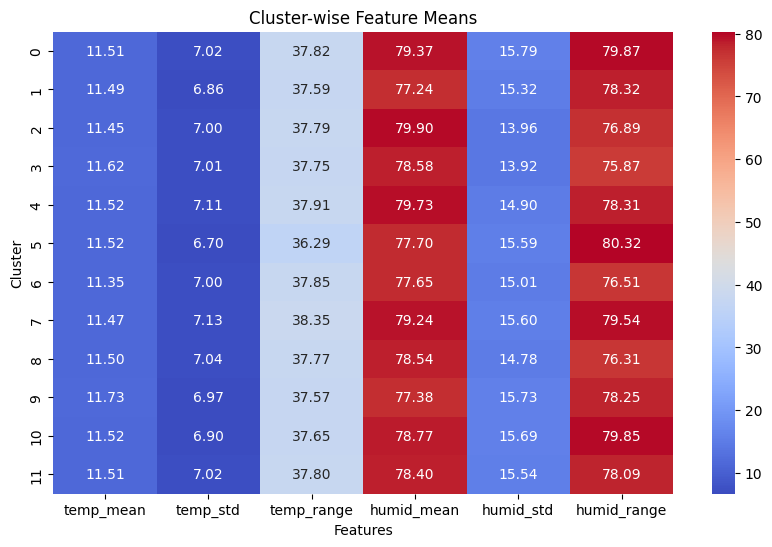

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_avg,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster-wise Feature Means")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

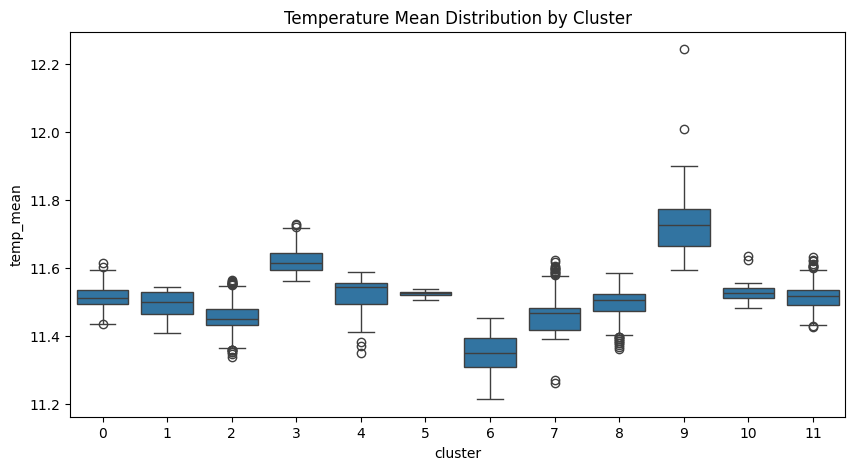

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="cluster",
    y="temp_mean"
)

plt.title("Temperature Mean Distribution by Cluster")
plt.show()

In [ ]:
from scipy.spatial.distance import cdist

distance_matrix = pd.DataFrame(
    cdist(cluster_avg.values, cluster_avg.values),
    index=cluster_avg.index,
    columns=cluster_avg.index
)

print("\nDistance Between Cluster Centroids:\n")
print(distance_matrix.round(2))


Distance Between Cluster Centroids:

cluster    0     1     2     3     4     5     6     7     8     9     10  \
cluster                                                                     
0        0.00  2.69  3.54  4.49  1.84  2.34  3.86  0.68  3.79  2.59  0.64   
1        2.69  0.00  3.32  3.13  2.56  2.45  1.91  2.49  2.47  0.51  2.20   
2        3.54  3.32  0.00  1.68  1.72  4.65  2.51  3.24  1.69  3.39  3.61   
3        4.49  3.13  1.68  0.00  2.88  5.06  1.60  4.14  0.97  3.23  4.36   
4        1.84  2.56  1.72  2.88  0.00  3.38  2.76  1.56  2.34  2.53  2.01   
5        2.34  2.45  4.65  5.06  3.38  0.00  4.17  2.72  4.44  2.48  1.81   
6        3.86  1.91  2.51  1.60  2.76  4.17  0.00  3.51  0.96  1.96  3.60   
7        0.68  2.49  3.24  4.14  1.56  2.72  3.51  0.00  3.46  2.42  0.93   
8        3.79  2.47  1.69  0.97  2.34  4.44  0.96  3.46  0.00  2.47  3.67   
9        2.59  0.51  3.39  3.23  2.53  2.48  1.96  2.42  2.47  0.00  2.13   
10       0.64  2.20  3.61  4.36  2.01 

#Data Generation for UI

In [ ]:
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from datetime import datetime, timedelta

np.random.seed(42)

# =========================================================
# 1. FIELD GENERATION (IRREGULAR POLYGON ~6000 GRID POINTS)
# =========================================================

center_lat = 28.6139
center_lon = 77.2090

half_side_m = 190  # controls total grid size (~5000–7000 points)

radius_lat = half_side_m / 111000
radius_lon = half_side_m / (111000 * np.cos(np.radians(center_lat)))

num_vertices = 18
angles = np.linspace(0, 2*np.pi, num_vertices, endpoint=False)

points = []

for angle in angles:
    distortion = 1 + 0.15*np.random.rand()

    lat = center_lat + radius_lat * distortion * np.sin(angle)
    lon = center_lon + radius_lon * distortion * np.cos(angle)

    points.append((lat, lon))

# IMPORTANT: sort to form proper polygon
def angle_from_center(p):
    return np.arctan2(p[0] - center_lat, p[1] - center_lon)

points = sorted(points, key=angle_from_center)

df_field = pd.DataFrame(points, columns=["latitude", "longitude"])
df_field.to_csv("field_polygon.csv", index=False)

print("✅ field_polygon.csv created")


# =========================================================
# 2. SENSOR GENERATION (UNIFORM DISTRIBUTION)
# =========================================================

polygon = Polygon(zip(df_field["longitude"], df_field["latitude"]))

minx, miny, maxx, maxy = polygon.bounds

# dense grid → filter → evenly pick
grid_x = np.linspace(minx, maxx, 30)
grid_y = np.linspace(miny, maxy, 30)

candidates = []

for x in grid_x:
    for y in grid_y:
        if polygon.contains(Point(x, y)):
            candidates.append((y, x))  # lat, lon

candidates = np.array(candidates)

num_sensors = 40

indices = np.linspace(0, len(candidates) - 1, num_sensors).astype(int)
selected = candidates[indices]

df_sensors = pd.DataFrame({
    "sensor_id": range(1, num_sensors + 1),
    "latitude": selected[:, 0],
    "longitude": selected[:, 1]
})

df_sensors.to_csv("sensor_coordinates.csv", index=False)

print("✅ sensor_coordinates.csv created")


# =========================================================
# 3. SENSOR TIME SERIES DATA (FAST + REALISTIC)
# =========================================================

start_date = datetime(2023, 1, 1)

days = 60  # keep small for speed
hours = days * 24

records = []

for _, row in df_sensors.iterrows():

    sensor_id = int(row["sensor_id"])

    base_temp = 25 + np.random.uniform(-2, 2)
    base_humidity = 60 + np.random.uniform(-8, 8)

    for h in range(hours):

        timestamp = start_date + timedelta(hours=h)
        hour = timestamp.hour

        temp = base_temp + 5*np.sin(2*np.pi * hour / 24) + np.random.normal(0, 0.5)
        humidity = base_humidity - 10*np.sin(2*np.pi * hour / 24) + np.random.normal(0, 1)

        soil_moisture = 30 + np.random.normal(0, 2)
        wind_speed = 3 + np.random.normal(0, 0.8)
        solar = max(0, 800*np.sin(np.pi * hour / 24) + np.random.normal(0, 20))

        records.append([
            sensor_id,
            timestamp,
            temp,
            humidity,
            soil_moisture,
            wind_speed,
            solar
        ])

df_data = pd.DataFrame(records, columns=[
    "sensor_id",
    "timestamp",
    "temperature",
    "humidity",
    "soil_moisture",
    "wind_speed",
    "solar_radiation"
])

df_data.to_csv("sensor_data.csv", index=False)

print("✅ sensor_data.csv created")


# =========================================================
# DONE
# =========================================================

print("\n🎉 All files generated successfully!")
print("Files:")
print(" - field_polygon.csv")
print(" - sensor_coordinates.csv")
print(" - sensor_data.csv")

✅ field_polygon.csv created
✅ sensor_coordinates.csv created
✅ sensor_data.csv created

🎉 All files generated successfully!
Files:
 - field_polygon.csv
 - sensor_coordinates.csv
 - sensor_data.csv
